In [1]:
# %pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift
import time
notebook_start = time.perf_counter()

import  os
import  json
import  pandas as pd
import  numpy as np
import  joblib
import  thermoift.PLOT_SETTINGS as ps
from    thermoift import MLPostprocessing, MLPreprocessing
from    thermoift.rng_utils import get_rng
from    thermoift import plot_correlation_heatmap, print_model_metrics
from    sklearn.preprocessing import StandardScaler
from    sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from    sklearn.gaussian_process import GaussianProcessRegressor
from    sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from    sklearn.pipeline import Pipeline
from    sklearn.metrics import r2_score as _r2, mean_absolute_error as _mae
from    threadpoolctl import threadpool_info, threadpool_limits

In [2]:
OUTPUT_FOLDER           = "GPR_RESIDUAL_OUTPUTS"
SEED                    = 4555525
EXPERIMENT_MAX_SAMPLES  = 300  # Set to None to use the full dataset
RESTART_OPTIMIZER       = 1

# Stratified split/sampling settings
STRAT_BINS_SAMPLING     = 10    # T-P quantile bins used during stratified sampling
STRAT_BINS_SPLIT        = 4     # T-P quantile bins used for train/test/val split (q=4 -> 13 strata, safe down to 1000 samples)

# Cross-validation settings
RUN_CV                  = False  # set False to skip (~10 min on full dataset)
CV_FOLDS                = 5

CPU_THREADS = int(os.environ.get("SLURM_CPUS_PER_TASK", os.environ.get("OMP_NUM_THREADS", "1")))
THREADPOOL_CONTROLLER = threadpool_limits(limits=CPU_THREADS)
print(f"Requested CPU threads: {CPU_THREADS}")
print(f"Active threadpools: {threadpool_info()}")

Requested CPU threads: 1
Active threadpools: [{'user_api': 'blas', 'internal_api': 'openblas', 'num_threads': 1, 'prefix': 'libscipy_openblas', 'filepath': '/home/darshan/A6/py_A6/lib/python3.12/site-packages/numpy.libs/libscipy_openblas64_-fdde5778.so', 'version': '0.3.30', 'threading_layer': 'pthreads', 'architecture': 'SkylakeX'}, {'user_api': 'blas', 'internal_api': 'openblas', 'num_threads': 1, 'prefix': 'libscipy_openblas', 'filepath': '/home/darshan/A6/py_A6/lib/python3.12/site-packages/scipy.libs/libscipy_openblas-b75cc656.so', 'version': '0.3.29.dev', 'threading_layer': 'pthreads', 'architecture': 'SkylakeX'}, {'user_api': 'openmp', 'internal_api': 'openmp', 'num_threads': 1, 'prefix': 'libgomp', 'filepath': '/home/darshan/A6/py_A6/lib/python3.12/site-packages/scikit_learn.libs/libgomp-a34b3233.so.1.0.0', 'version': None}]


In [3]:
df          = pd.read_csv("../CombinedDatasetSEC_A4.csv")
df.columns  = [col.strip().replace(" ", "_") for col in df.columns]

# Keep only rows needed to calculate gamma_cDFT and residual
df = df.dropna(subset=["gamma_wsd","gamma_cDFT_minus_wsd_uncorrected","gamma_wsd_UC"]).copy()

# Recalculate gamma_cDFT
df["gamma_cDFT_UC"] = df["gamma_wsd_UC"] + df["gamma_cDFT_minus_wsd_uncorrected"]
df["gamma_cDFT"]    = df["gamma_wsd"]    + df["gamma_cDFT_minus_wsd_corrected"]

# Residual
df["residual"]   = df["gamma_cDFT_UC"] - df["gamma_wsd_UC"]

tol = 1e-10
# Check gamma_cDFT_UC vs gamma_cDFT
diff_gamma = df["gamma_cDFT_UC"] - df["gamma_cDFT"]
mask_gamma = diff_gamma.abs() > tol

if mask_gamma.any():
    print(f"WARNING: {mask_gamma.sum()} rows have mismatched gamma_cDFT values.")

    print(df.loc[mask_gamma, [
        "source_id",
        "gamma_cDFT_UC",
        "gamma_cDFT"
    ]].assign(difference=diff_gamma[mask_gamma]))
else:
    print("All gamma_cDFT values match within tolerance.")

All gamma_cDFT values match within tolerance.


In [4]:
if EXPERIMENT_MAX_SAMPLES is not None:
    # Stratified sampling over T–P bins to guarantee coverage of rare regions
    df["_T_bin"]    = pd.qcut(df["T"], q=STRAT_BINS_SAMPLING, labels=False, duplicates="drop")
    df["_P_bin"]    = pd.qcut(df["P"], q=STRAT_BINS_SAMPLING, labels=False, duplicates="drop")
    df["_stratum"]  = df["_T_bin"].astype(str) + "_" + df["_P_bin"].astype(str)
    n_target        = min(EXPERIMENT_MAX_SAMPLES, len(df))
    df = (
        df.groupby("_stratum", group_keys=False)
          .apply(lambda g: g.sample(
              n=max(1, round(n_target * len(g) / len(df))),
              random_state=SEED,
          ))
          .sample(frac=1, random_state=SEED)  # shuffle
          .head(n_target)                     # exact cap
          .drop(columns=["_T_bin", "_P_bin", "_stratum"])
          .reset_index(drop=True)
    )

print(f"Total active samples: {len(df)}")
print(f"Experiment sample cap: {EXPERIMENT_MAX_SAMPLES}")
print(f"Residual statistics:")
print(df["residual"].describe())

Total active samples: 300
Experiment sample cap: 300
Residual statistics:
count    300.000000
mean      -0.501794
std        0.549216
min       -3.195675
25%       -0.698096
50%       -0.300394
75%       -0.117532
max       -0.010522
Name: residual, dtype: float64


/tmp/ipykernel_997632/3893283935.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(


In [5]:
target          = "residual"
rng             = get_rng(seed=SEED)

z_columns       = [col for col in df.columns if col.startswith("z_")]
DROP_FEATURES   = ["z_oxygen"]
Z_non_zero      = [col for col in z_columns if (df[col] != 0).any() and col not in DROP_FEATURES]
features        = ["T", "P"] + Z_non_zero

print(f"Selected features: {features}")

X               = df[features]
y               = df[target]

# Stratified 70/15/15 split using T-P bins
_T_bin   = pd.qcut(X["T"], q=STRAT_BINS_SPLIT, labels=False, duplicates="drop")
_P_bin   = pd.qcut(X["P"], q=STRAT_BINS_SPLIT, labels=False, duplicates="drop")
_stratum = _T_bin.astype(str) + "_" + _P_bin.astype(str)

X_train, X_temp, y_train, y_temp, s_train, s_temp = train_test_split(
    X, y, _stratum, test_size=0.30, random_state=SEED, stratify=_stratum
)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=s_temp
)

print(f"Training samples:   {X_train.shape[0]}")
print(f"Testing samples:      {X_test.shape[0]}")
print(f"Validation samples:   {X_val.shape[0]}")

Selected features: ['T', 'P', 'z_argon', 'z_carbon_dioxide', 'z_carbon_monoxide', 'z_hydrogen', 'z_hydrogen_sulfide', 'z_methane', 'z_nitrogen']
Training samples:   210
Testing samples:      45
Validation samples:   45


Feature correlations with residual:
T                     0.540055
z_carbon_dioxide      0.312565
z_hydrogen_sulfide   -0.009283
z_argon              -0.025994
z_nitrogen           -0.034772
z_carbon_monoxide    -0.060819
z_methane            -0.068372
P                    -0.122295
z_hydrogen           -0.294541
Name: residual, dtype: float64


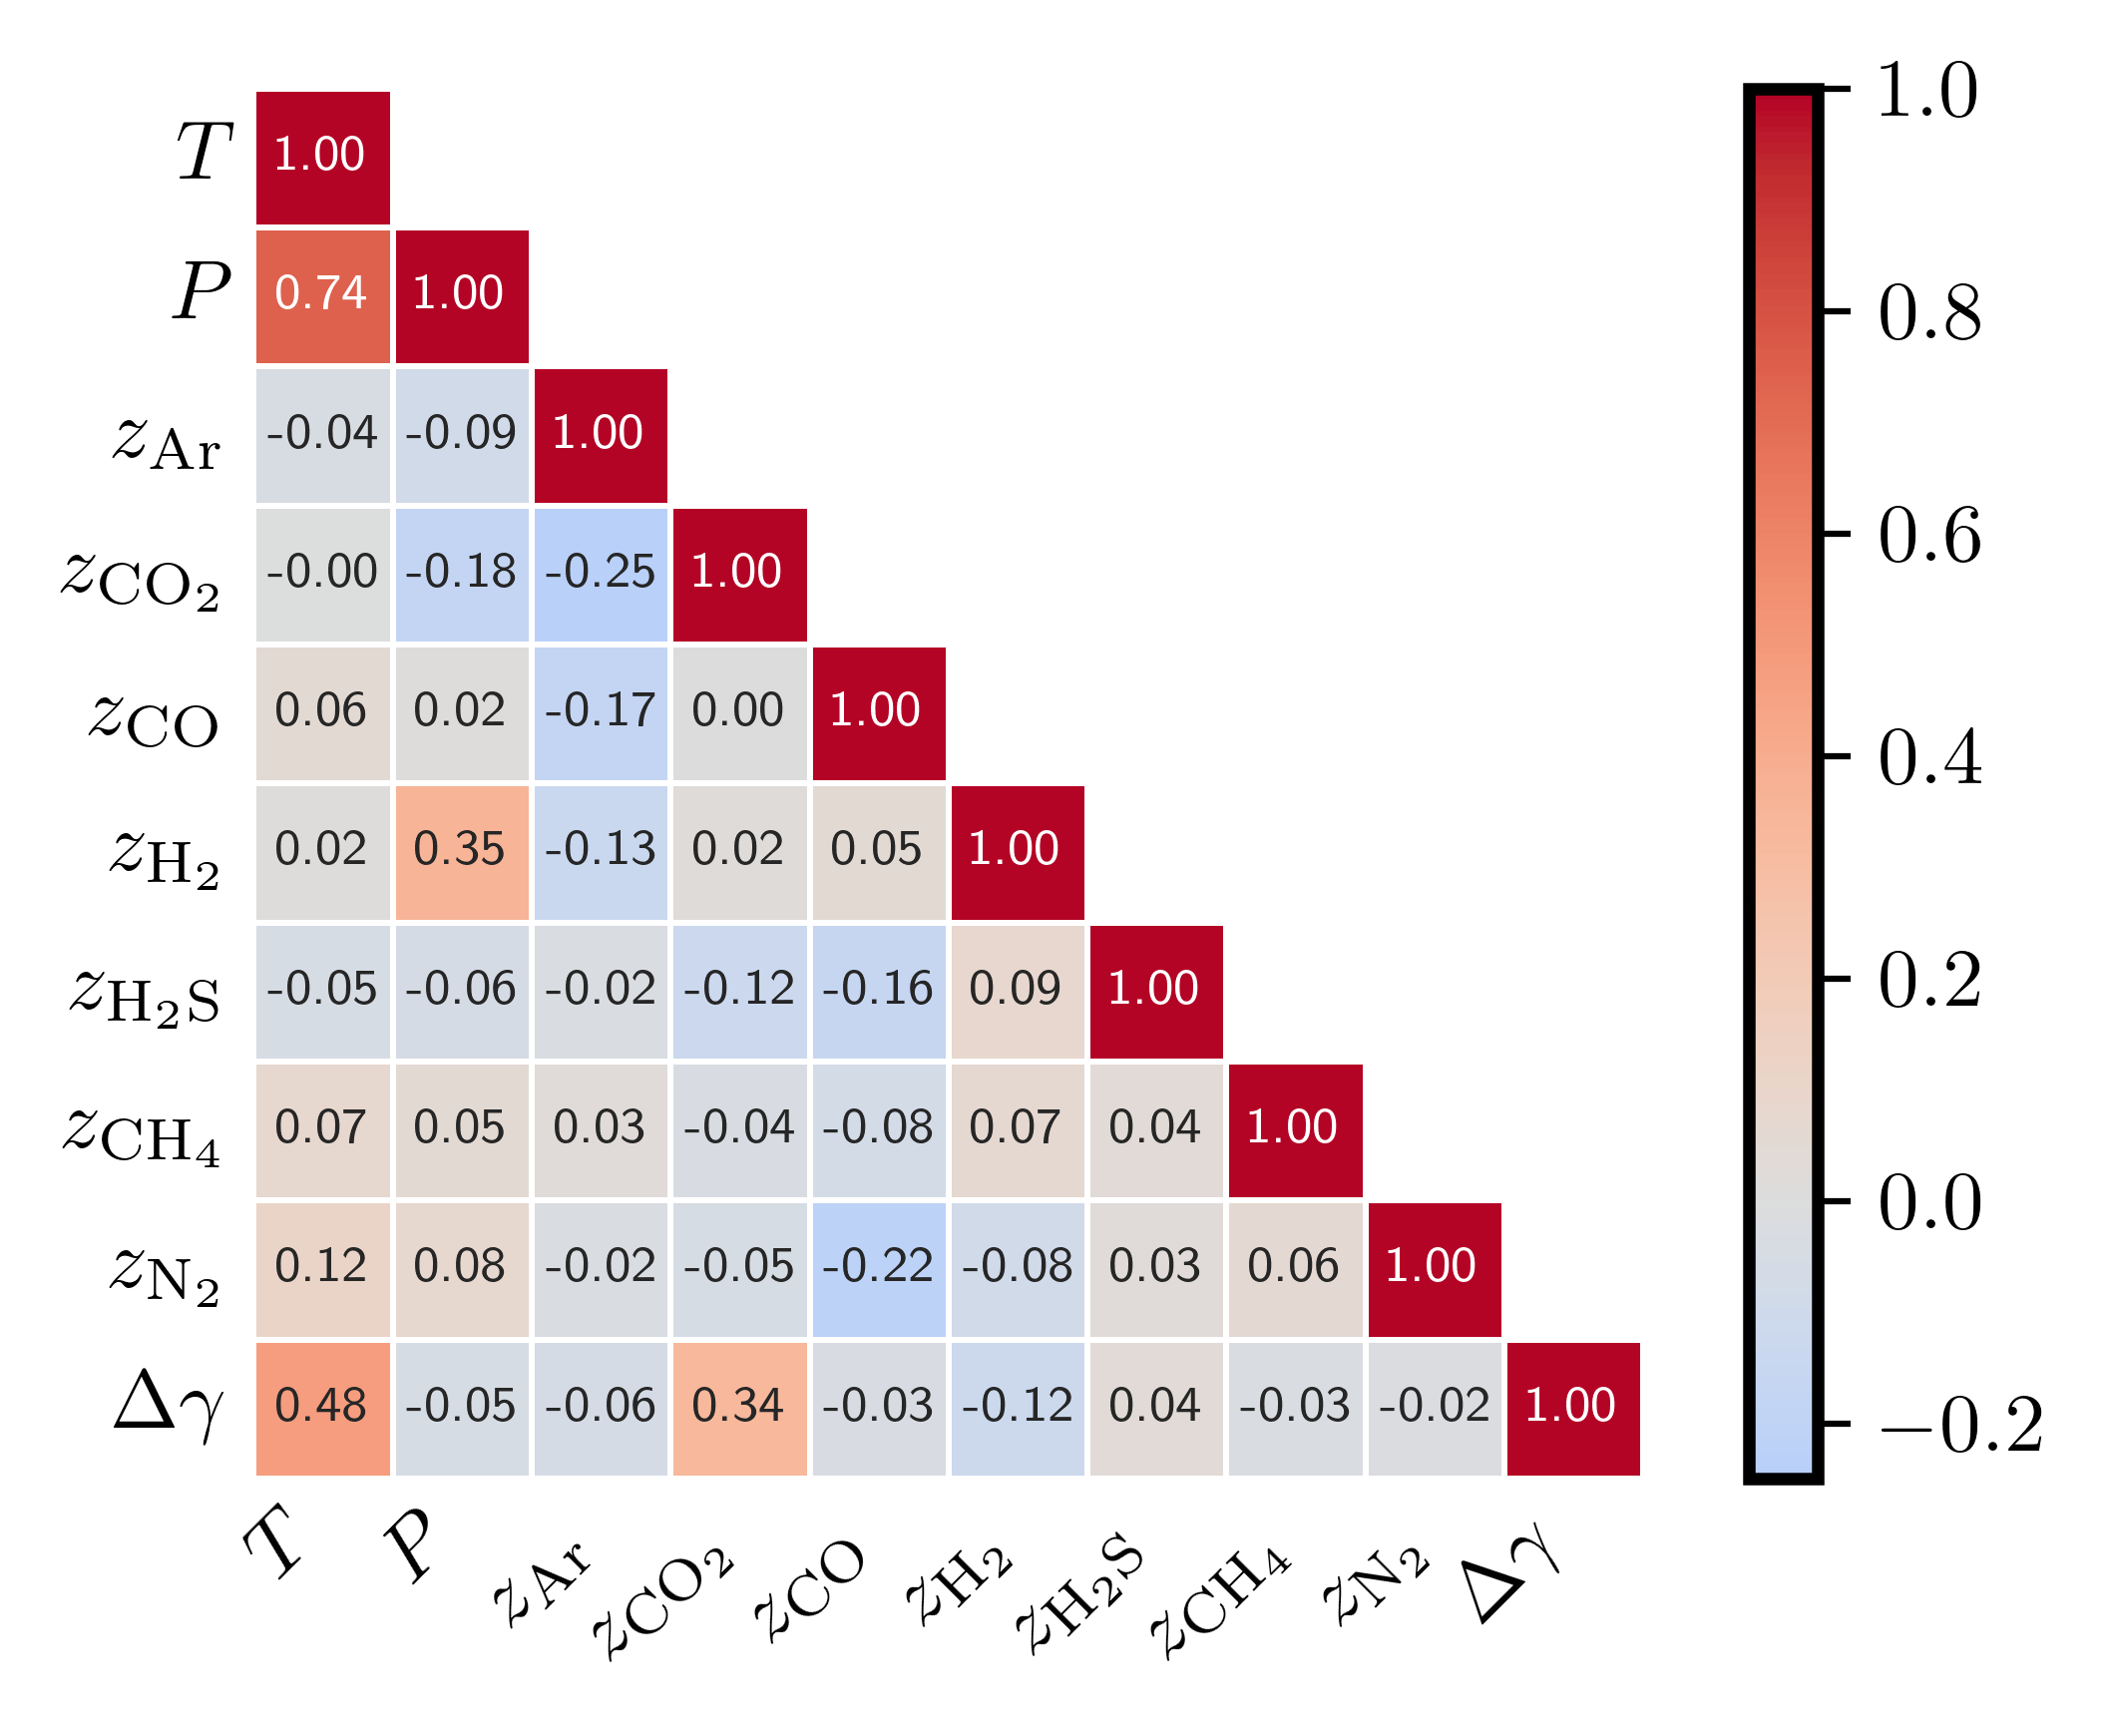

(<Figure size 2400x1800 with 2 Axes>, <Axes: >)

In [6]:
plot_correlation_heatmap(df, features, target, save_path="GPR_residual_correlation", folder=OUTPUT_FOLDER)

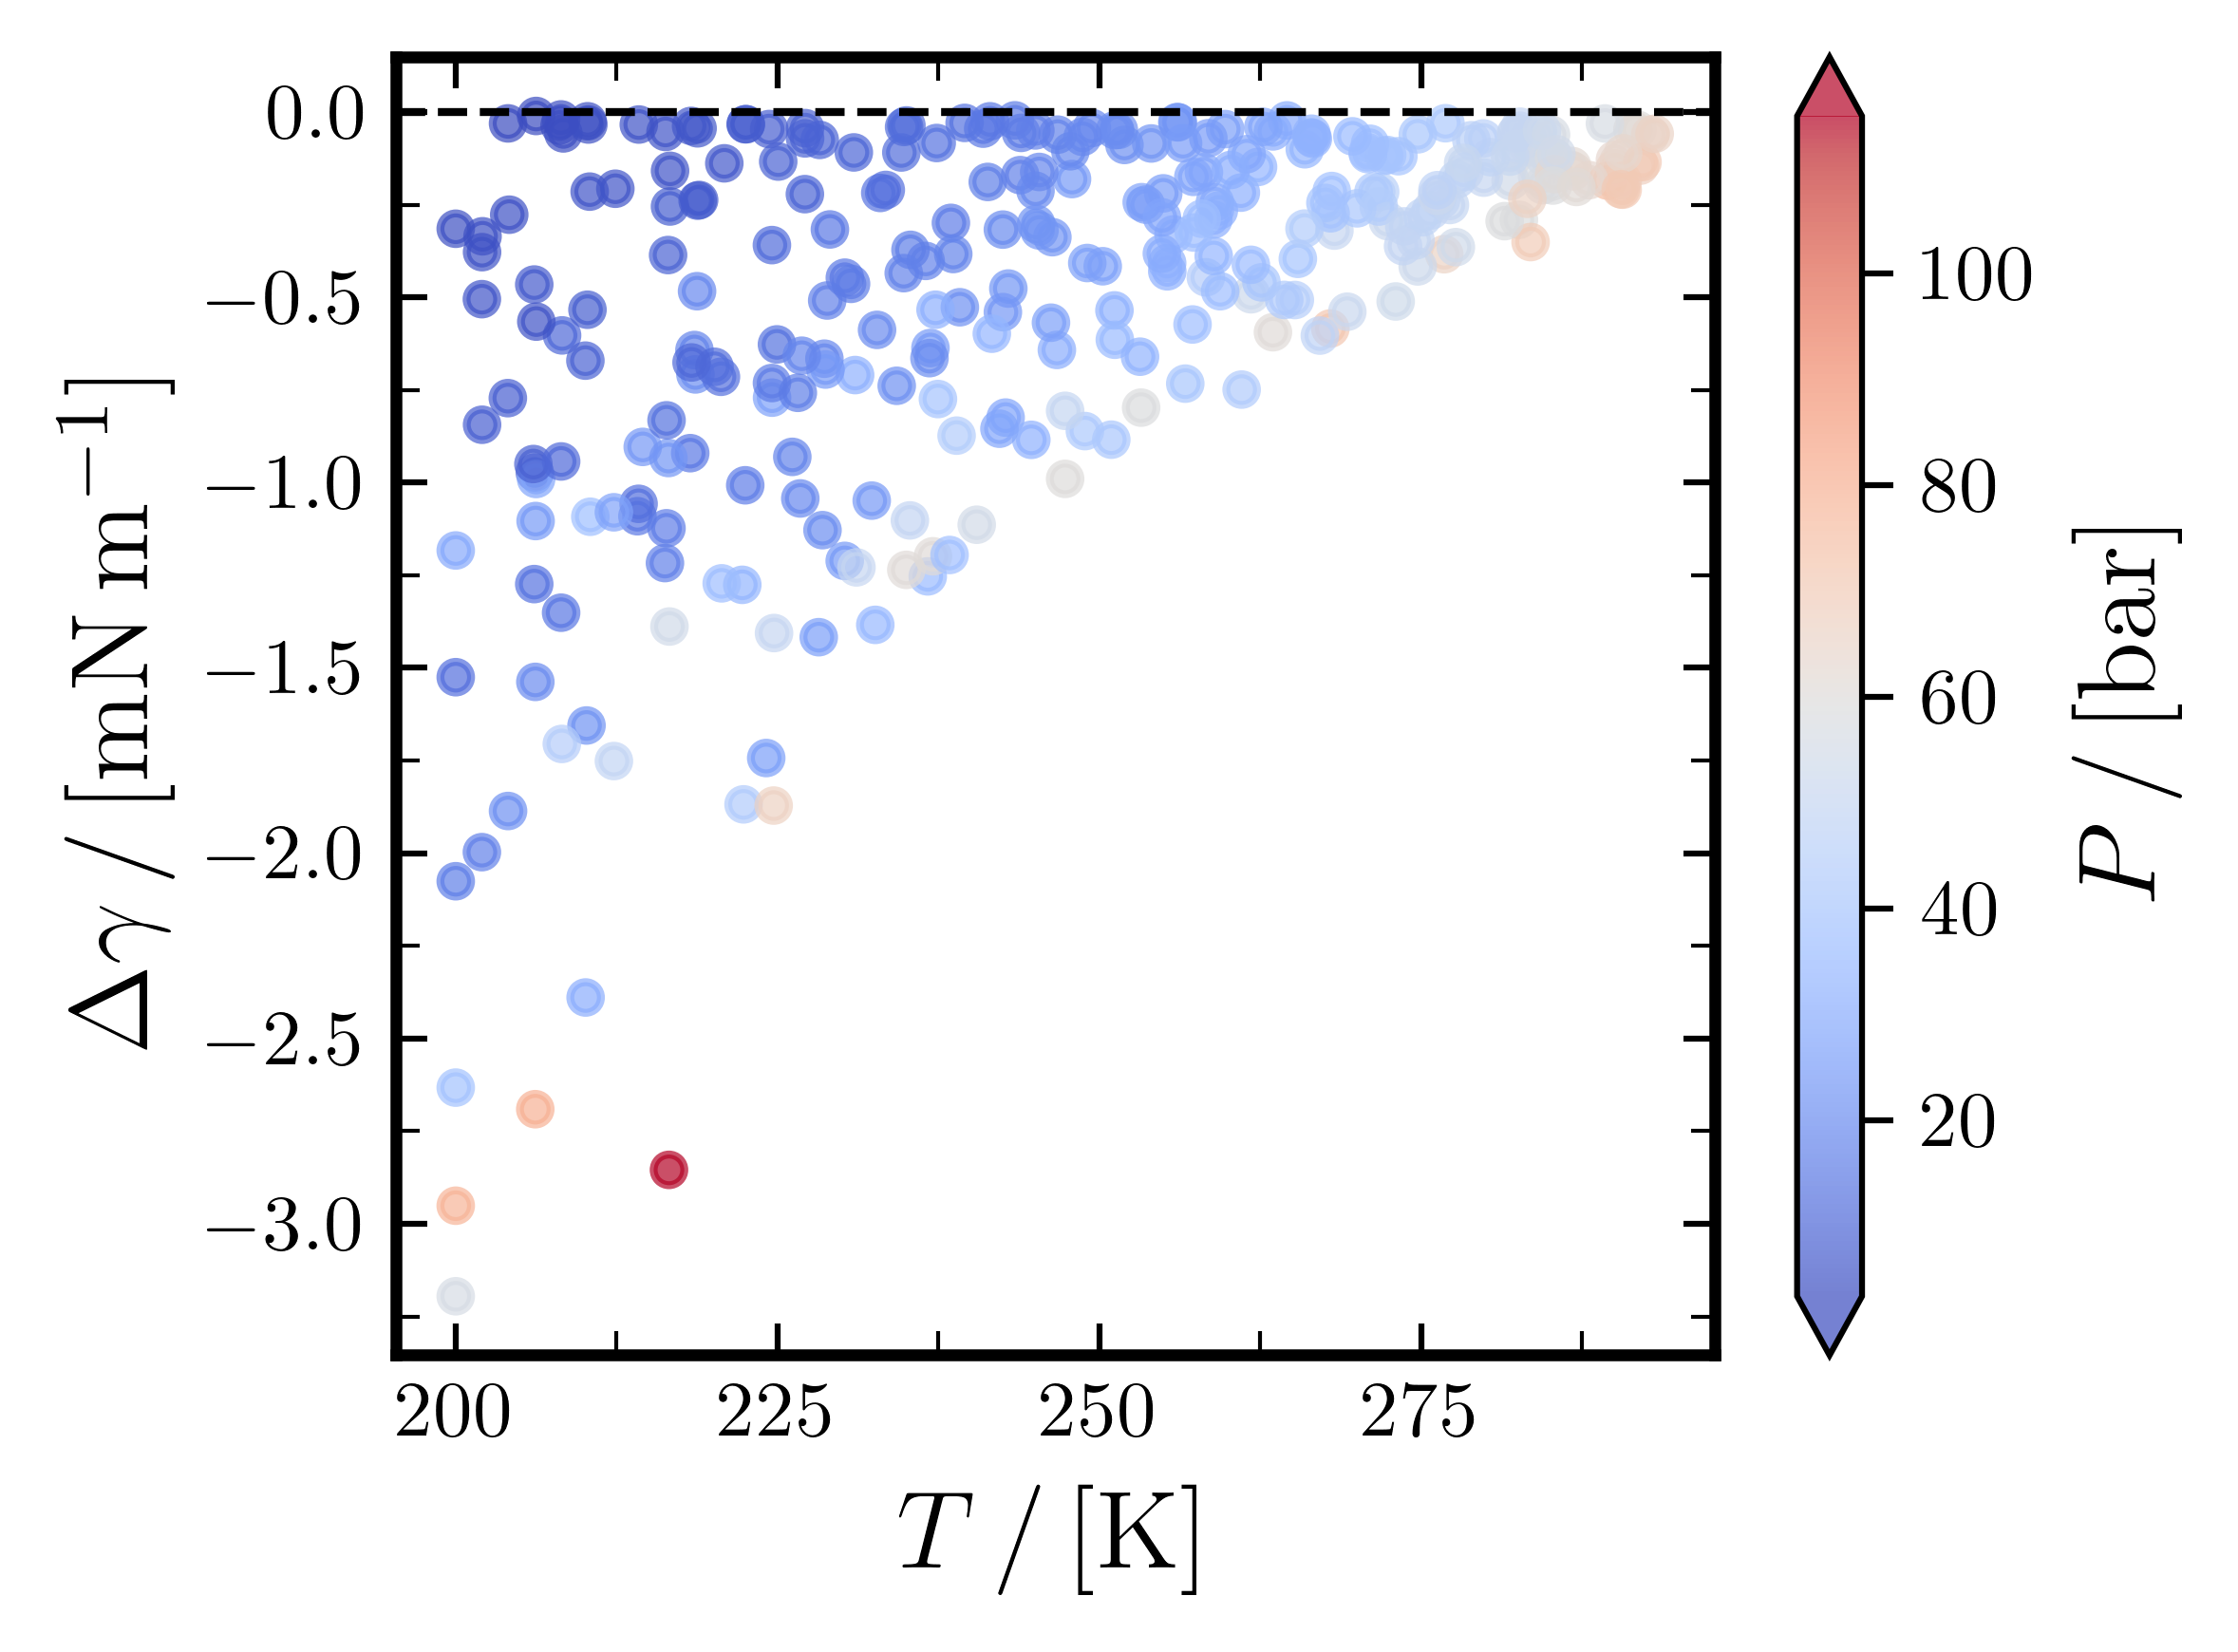

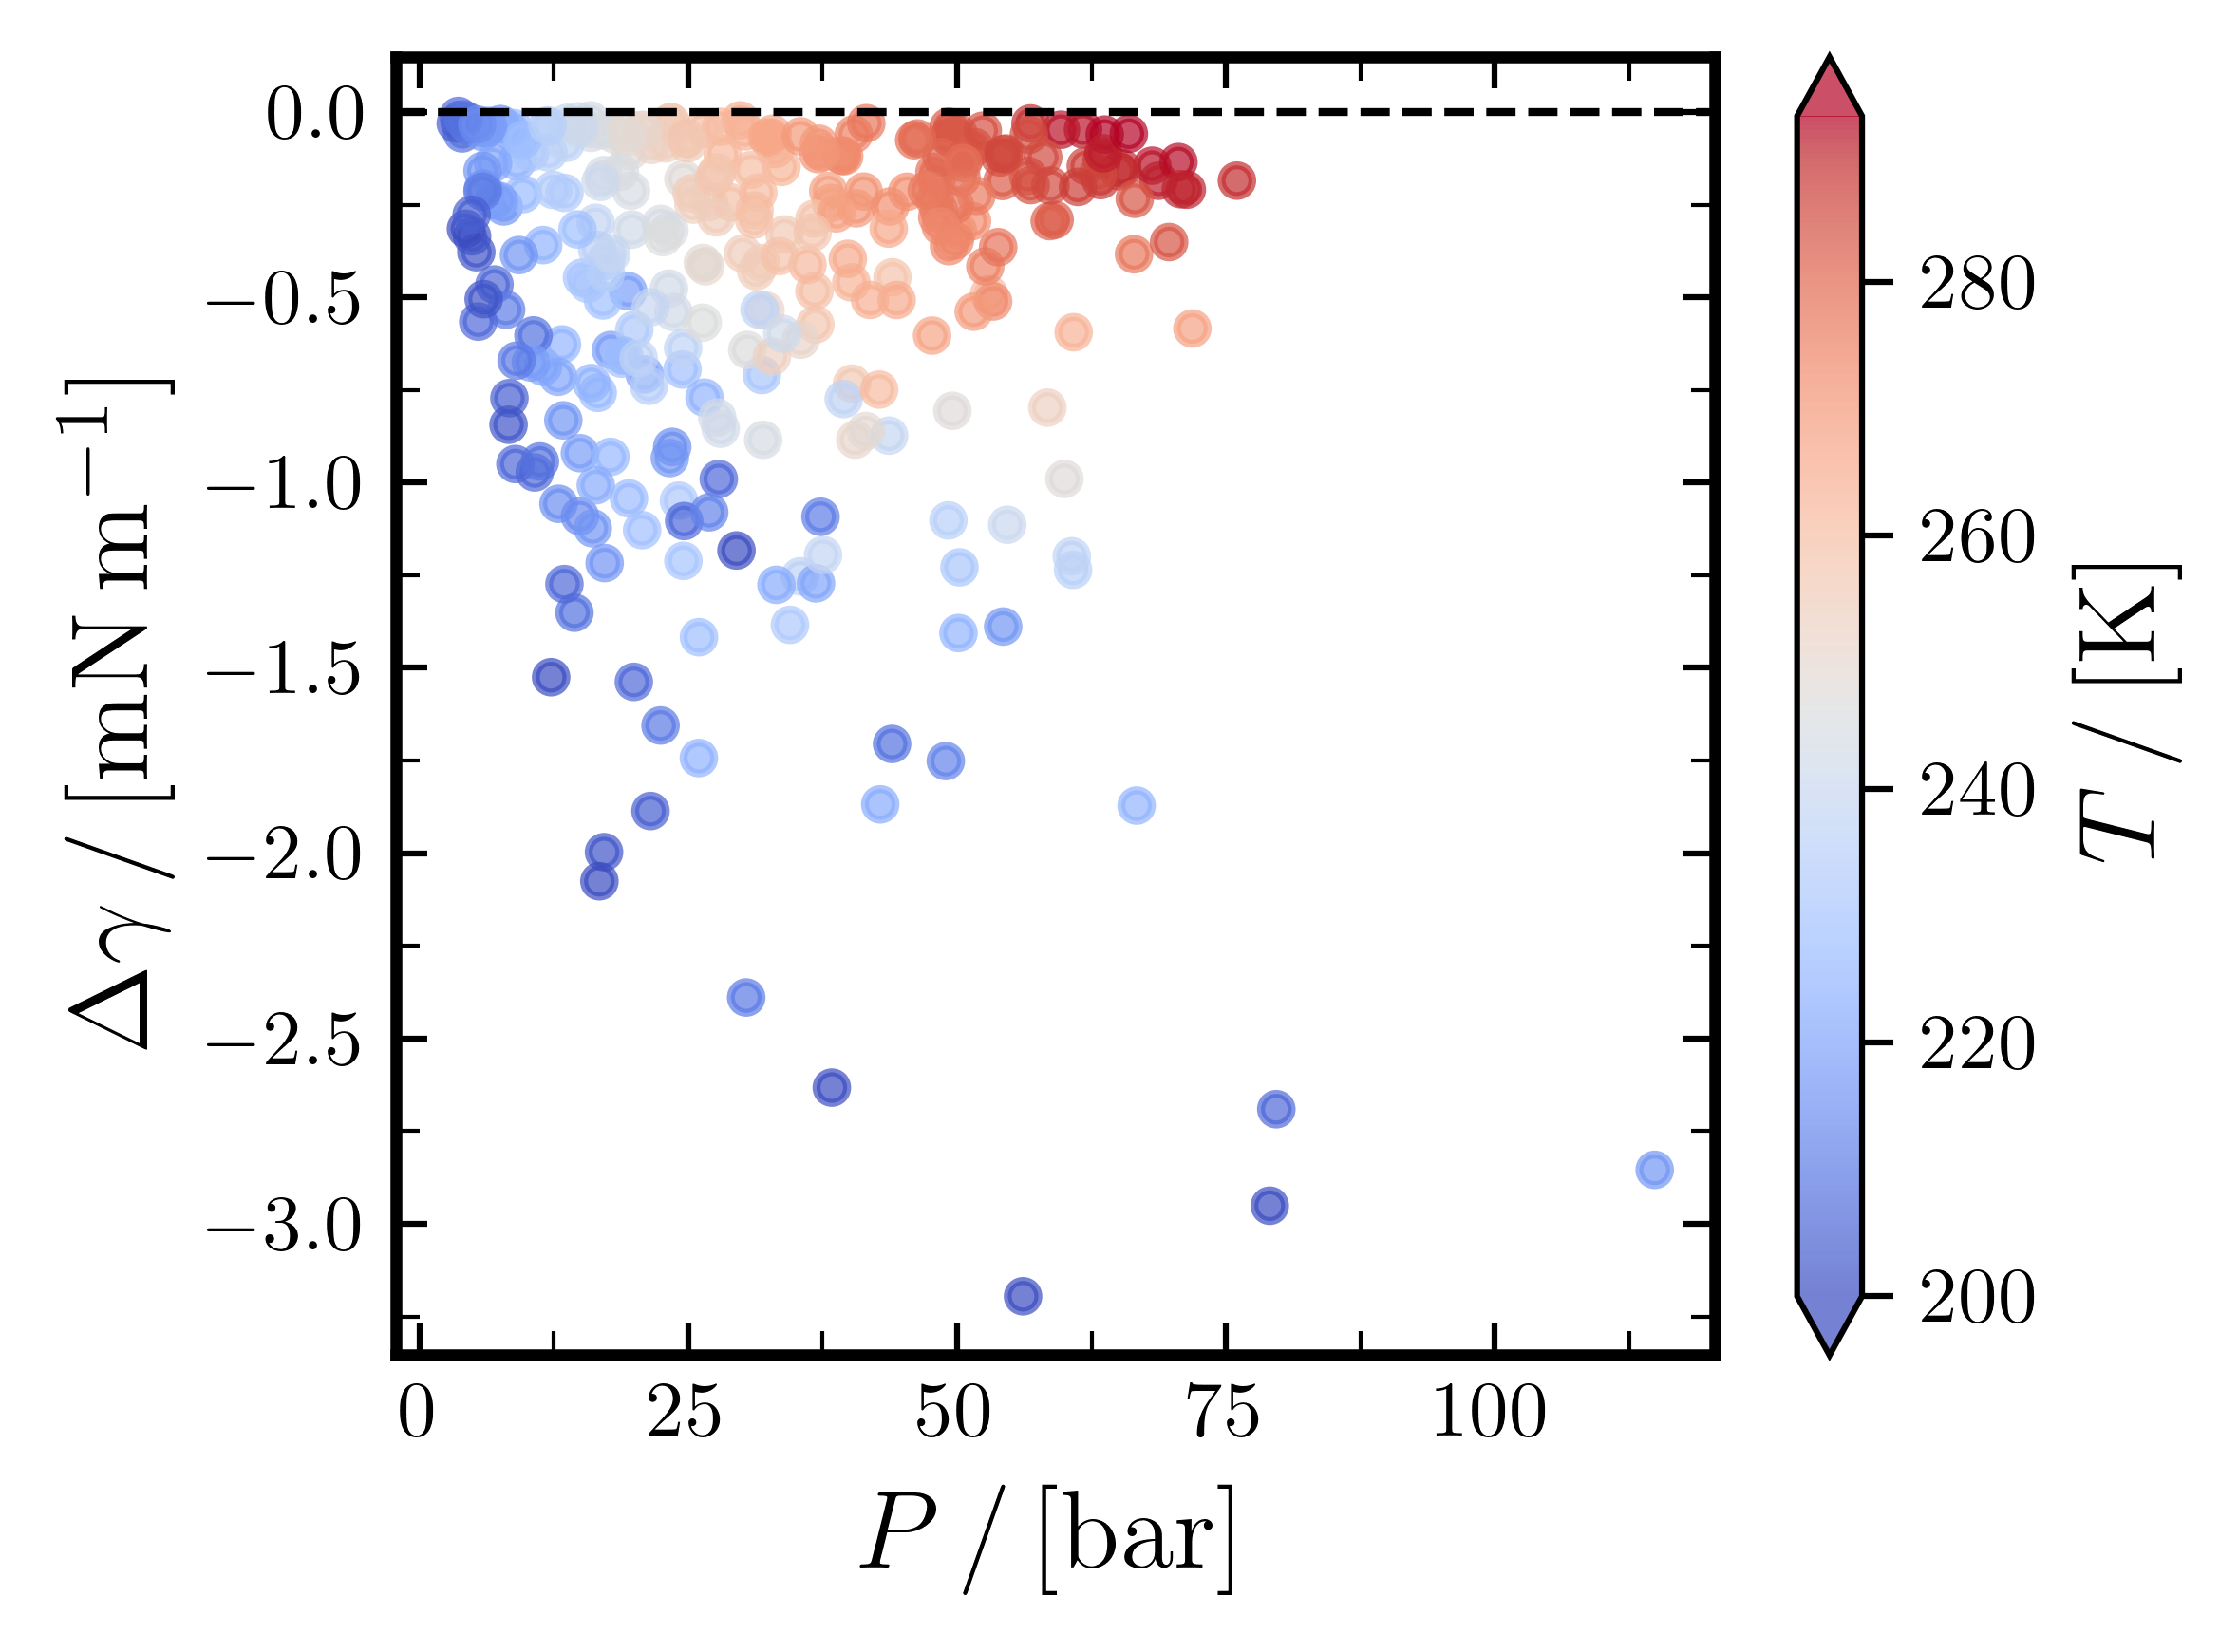

(<Figure size 2400x1800 with 2 Axes>,
 <Axes: xlabel='$P \\, / \\, [\\mathrm{bar}]$', ylabel='$\\Delta \\gamma \\, / \\, [\\mathrm{mN} \\, \\mathrm{m}^{-1}]$'>)

In [7]:
prep = MLPreprocessing(df=df, features=features, target=target)

prep.plot_scatter(
    x           = "T",
    y           = target,
    color_by    = "P",
    hline       = 0.0,
    save_path   = "GPR_residual_vs_T",
    folder      = OUTPUT_FOLDER,
)

prep.plot_scatter(
    x           = "P",
    y           = target,
    color_by    = "T",
    hline       = 0.0,
    save_path   = "GPR_residual_vs_P",
    folder      = OUTPUT_FOLDER,
)

In [8]:
# ── Baseline over/underprediction inspection ─────────────────────────────────
# Δγ < 0  →  baseline OVERpredicts  γ_cDFT  (most negative residuals)
# Δγ > 0  →  baseline UNDERpredicts γ_cDFT  (most positive residuals)
N = 10

z_cols    = [c for c in features if c.startswith("z_")]
z_non_co2 = [c for c in z_cols if c != "z_carbon_dioxide"]

inspect = df[features + [target]].copy()
inspect["source_id"]        = df["source_id"].values
inspect["dominant_species"] = inspect[z_non_co2].idxmax(axis=1).str.replace("z_", "")

cols_out = ["source_id", "dominant_species", "T", "P", target]

print(f"Top-{N} BASELINE OVERPREDICTIONS  (Δγ most negative — baseline too high):")
print(inspect.nsmallest(N, target)[cols_out].to_string(index=False))

print(f"Top-{N} BASELINE UNDERPREDICTIONS (Δγ most positive — baseline too low):")
print(inspect.nlargest(N, target)[cols_out].to_string(index=False))


Top-10 BASELINE OVERPREDICTIONS  (Δγ most negative — baseline too high):
 source_id dominant_species          T          P  residual
        56          methane 200.000000  56.135930 -3.195675
        24 hydrogen_sulfide 200.000000  79.076972 -2.951300
        21         hydrogen 216.563809 114.872549 -2.854577
        44         hydrogen 206.177586  79.686773 -2.690828
        56          methane 200.000000  38.355791 -2.632602
        37            argon 210.087884  30.394314 -2.389375
        45         nitrogen 200.000000  16.743520 -2.075668
        45         nitrogen 202.032078  17.176062 -1.997153
        43  carbon_monoxide 204.063065  21.494540 -1.886133
        38         hydrogen 224.694824  66.696627 -1.871482
Top-10 BASELINE UNDERPREDICTIONS (Δγ most positive — baseline too low):
 source_id dominant_species          T         P  residual
        33         hydrogen 206.243500  3.637949 -0.010522
        80         hydrogen 208.177793  4.117428 -0.019853
        74        

In [9]:
df["gamma_base"] = df["gamma_wsd_UC"]

print(df[["gamma_cDFT", "gamma_base", "residual"]].isna().sum())
print("Any NaN in X:", X.isna().any().any())
print("Any NaN in y:", y.isna().any())

gamma_cDFT    0
gamma_base    0
residual      0
dtype: int64
Any NaN in X: False
Any NaN in y: False


In [10]:
# Kernel 
#Choice1: const * RBF + WhiteKernel
n_features = X_train.shape[1]
kernel = (
    ConstantKernel(1.0, (1e-3, 1e3)) *
    RBF(length_scale=np.ones(n_features), length_scale_bounds=(1e-2, 1e3)) +
    WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e0))
)

# Pipeline
gpr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("gpr", GaussianProcessRegressor(
        kernel      = kernel,
        alpha       = 0.0,
        normalize_y = True,
        n_restarts_optimizer = RESTART_OPTIMIZER,
        random_state         = SEED,
    ))
]) 

# Fit
gpr_model.fit(X_train, y_train)

# Predictions
y_train_pred, y_train_std   = gpr_model.predict(X_train, return_std=True)
y_val_pred, y_val_std       = gpr_model.predict(X_val, return_std=True)
y_test_pred, y_test_std     = gpr_model.predict(X_test, return_std=True)

# Metrics
metrics = print_model_metrics(y_train, y_train_pred, y_test, y_test_pred, target, unit="mN/m", y_val=y_val, y_val_pred=y_val_pred)
metrics["train_mae_mNm"] = float(_mae(y_train, y_train_pred))
metrics["test_mae_mNm"]  = float(_mae(y_test,  y_test_pred))
metrics["val_mae_mNm"]   = float(_mae(y_val,   y_val_pred))
print(f"Residual MAE [mN/m] — train: {metrics['train_mae_mNm']:.6f} "
      f"| test: {metrics['test_mae_mNm']:.6f} "
      f"| val: {metrics['val_mae_mNm']:.6f}")

Model Performance for residual

Training Set:
  R²:   0.999993
  RMSE: 0.001452 mN/m
  MAE:  0.000873 mN/m

Test Set:
  R²:   0.953013
  RMSE: 0.128084 mN/m
  MAE:  0.059430 mN/m

Validation Set:
  R²:   0.949934
  RMSE: 0.119432 mN/m
  MAE:  0.043443 mN/m
Residual MAE [mN/m] — train: 0.000873 | test: 0.059430 | val: 0.043443


In [11]:
# 5-fold stratified cross-validation (same T-P binning used during sampling)
if RUN_CV:
    # Re-create stratum labels from X so each fold mirrors the T-P coverage
    _T_bin_cv = pd.qcut(X["T"], q=10, labels=False, duplicates="drop")
    _P_bin_cv = pd.qcut(X["P"], q=10, labels=False, duplicates="drop")
    _strata   = _T_bin_cv.astype(str) + "_" + _P_bin_cv.astype(str)

    _skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

    cv_r2_scores   = cross_val_score(gpr_model, X, y, cv=_skf.split(X, _strata), scoring='r2')
    cv_rmse_scores = -cross_val_score(gpr_model, X, y, cv=_skf.split(X, _strata), scoring='neg_root_mean_squared_error')
    cv_mae_scores  = -cross_val_score(gpr_model, X, y, cv=_skf.split(X, _strata), scoring='neg_mean_absolute_error')

    print(f"Cross-Validation R² Scores:   {cv_r2_scores}")
    print(f"Mean CV R²:   {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std() * 2:.6f})")
    print(f"Cross-Validation RMSE Scores: {cv_rmse_scores}")
    print(f"Mean CV RMSE: {cv_rmse_scores.mean():.6f} (+/- {cv_rmse_scores.std() * 2:.6f})")
    print(f"Cross-Validation MAE Scores:  {cv_mae_scores}")
    print(f"Mean CV MAE:  {cv_mae_scores.mean():.6f} (+/- {cv_mae_scores.std() * 2:.6f})")
else:
    cv_r2_scores   = np.array([])
    cv_rmse_scores = np.array([])
    cv_mae_scores  = np.array([])
    print("CV skipped (RUN_CV=False).")

CV skipped (RUN_CV=False).


In [12]:
# Initialize MLPostprocessing
# GPR ARD feature importance: inverse length scales from the RBF kernel
# Kernel structure: (ConstantKernel * RBF) + WhiteKernel -> k1.k2.length_scale
_length_scales          = gpr_model.named_steps["gpr"].kernel_.k1.k2.length_scale
_feature_importances    = 1.0 / _length_scales
_feature_importances    = _feature_importances / _feature_importances.sum()  # normalize

post = MLPostprocessing(
    y_true  =y_test,
    y_pred  =y_test_pred,
    target  ="delta_gamma",
    feature_importances =_feature_importances,
    feature_names       =features,
    datasets            ={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

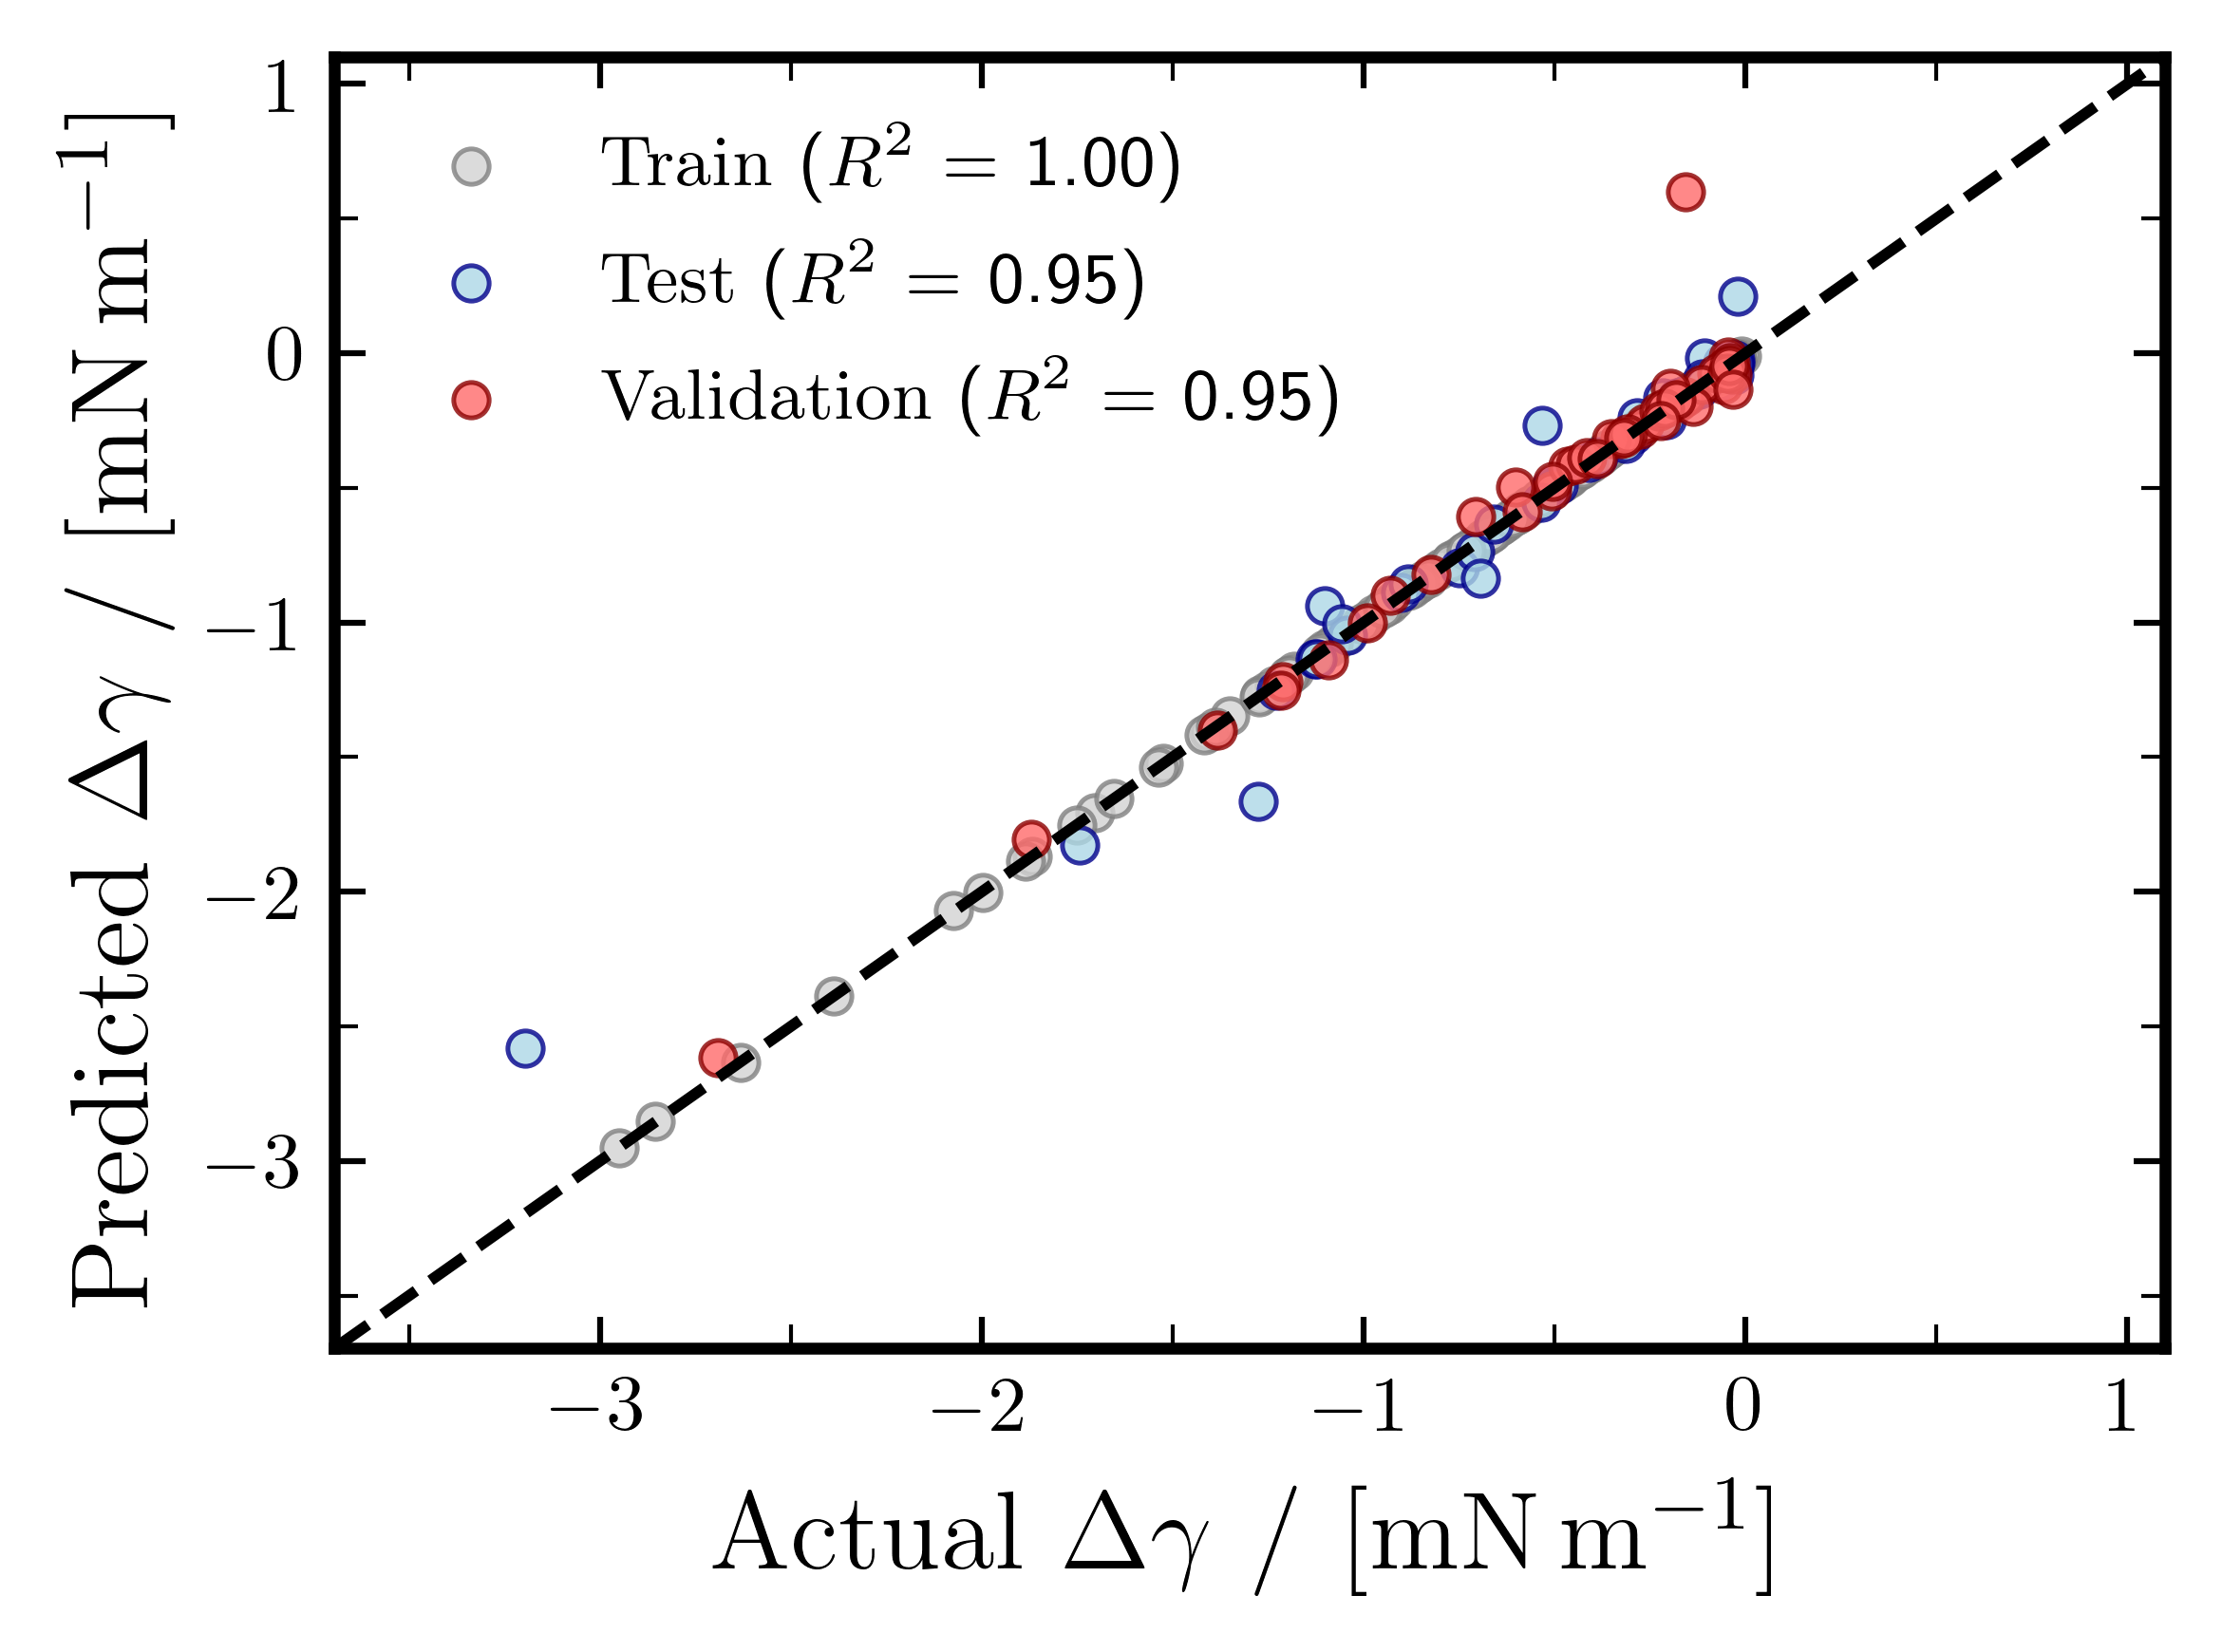

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Actual}$ $\\Delta\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$', ylabel='$\\mathrm{Predicted}$ $\\Delta\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$'>)

In [13]:
# Parity plot
post.plot_parity(model_name="GPR (RBF)", save_path="GPR_gamma_parity_plot", folder=OUTPUT_FOLDER)

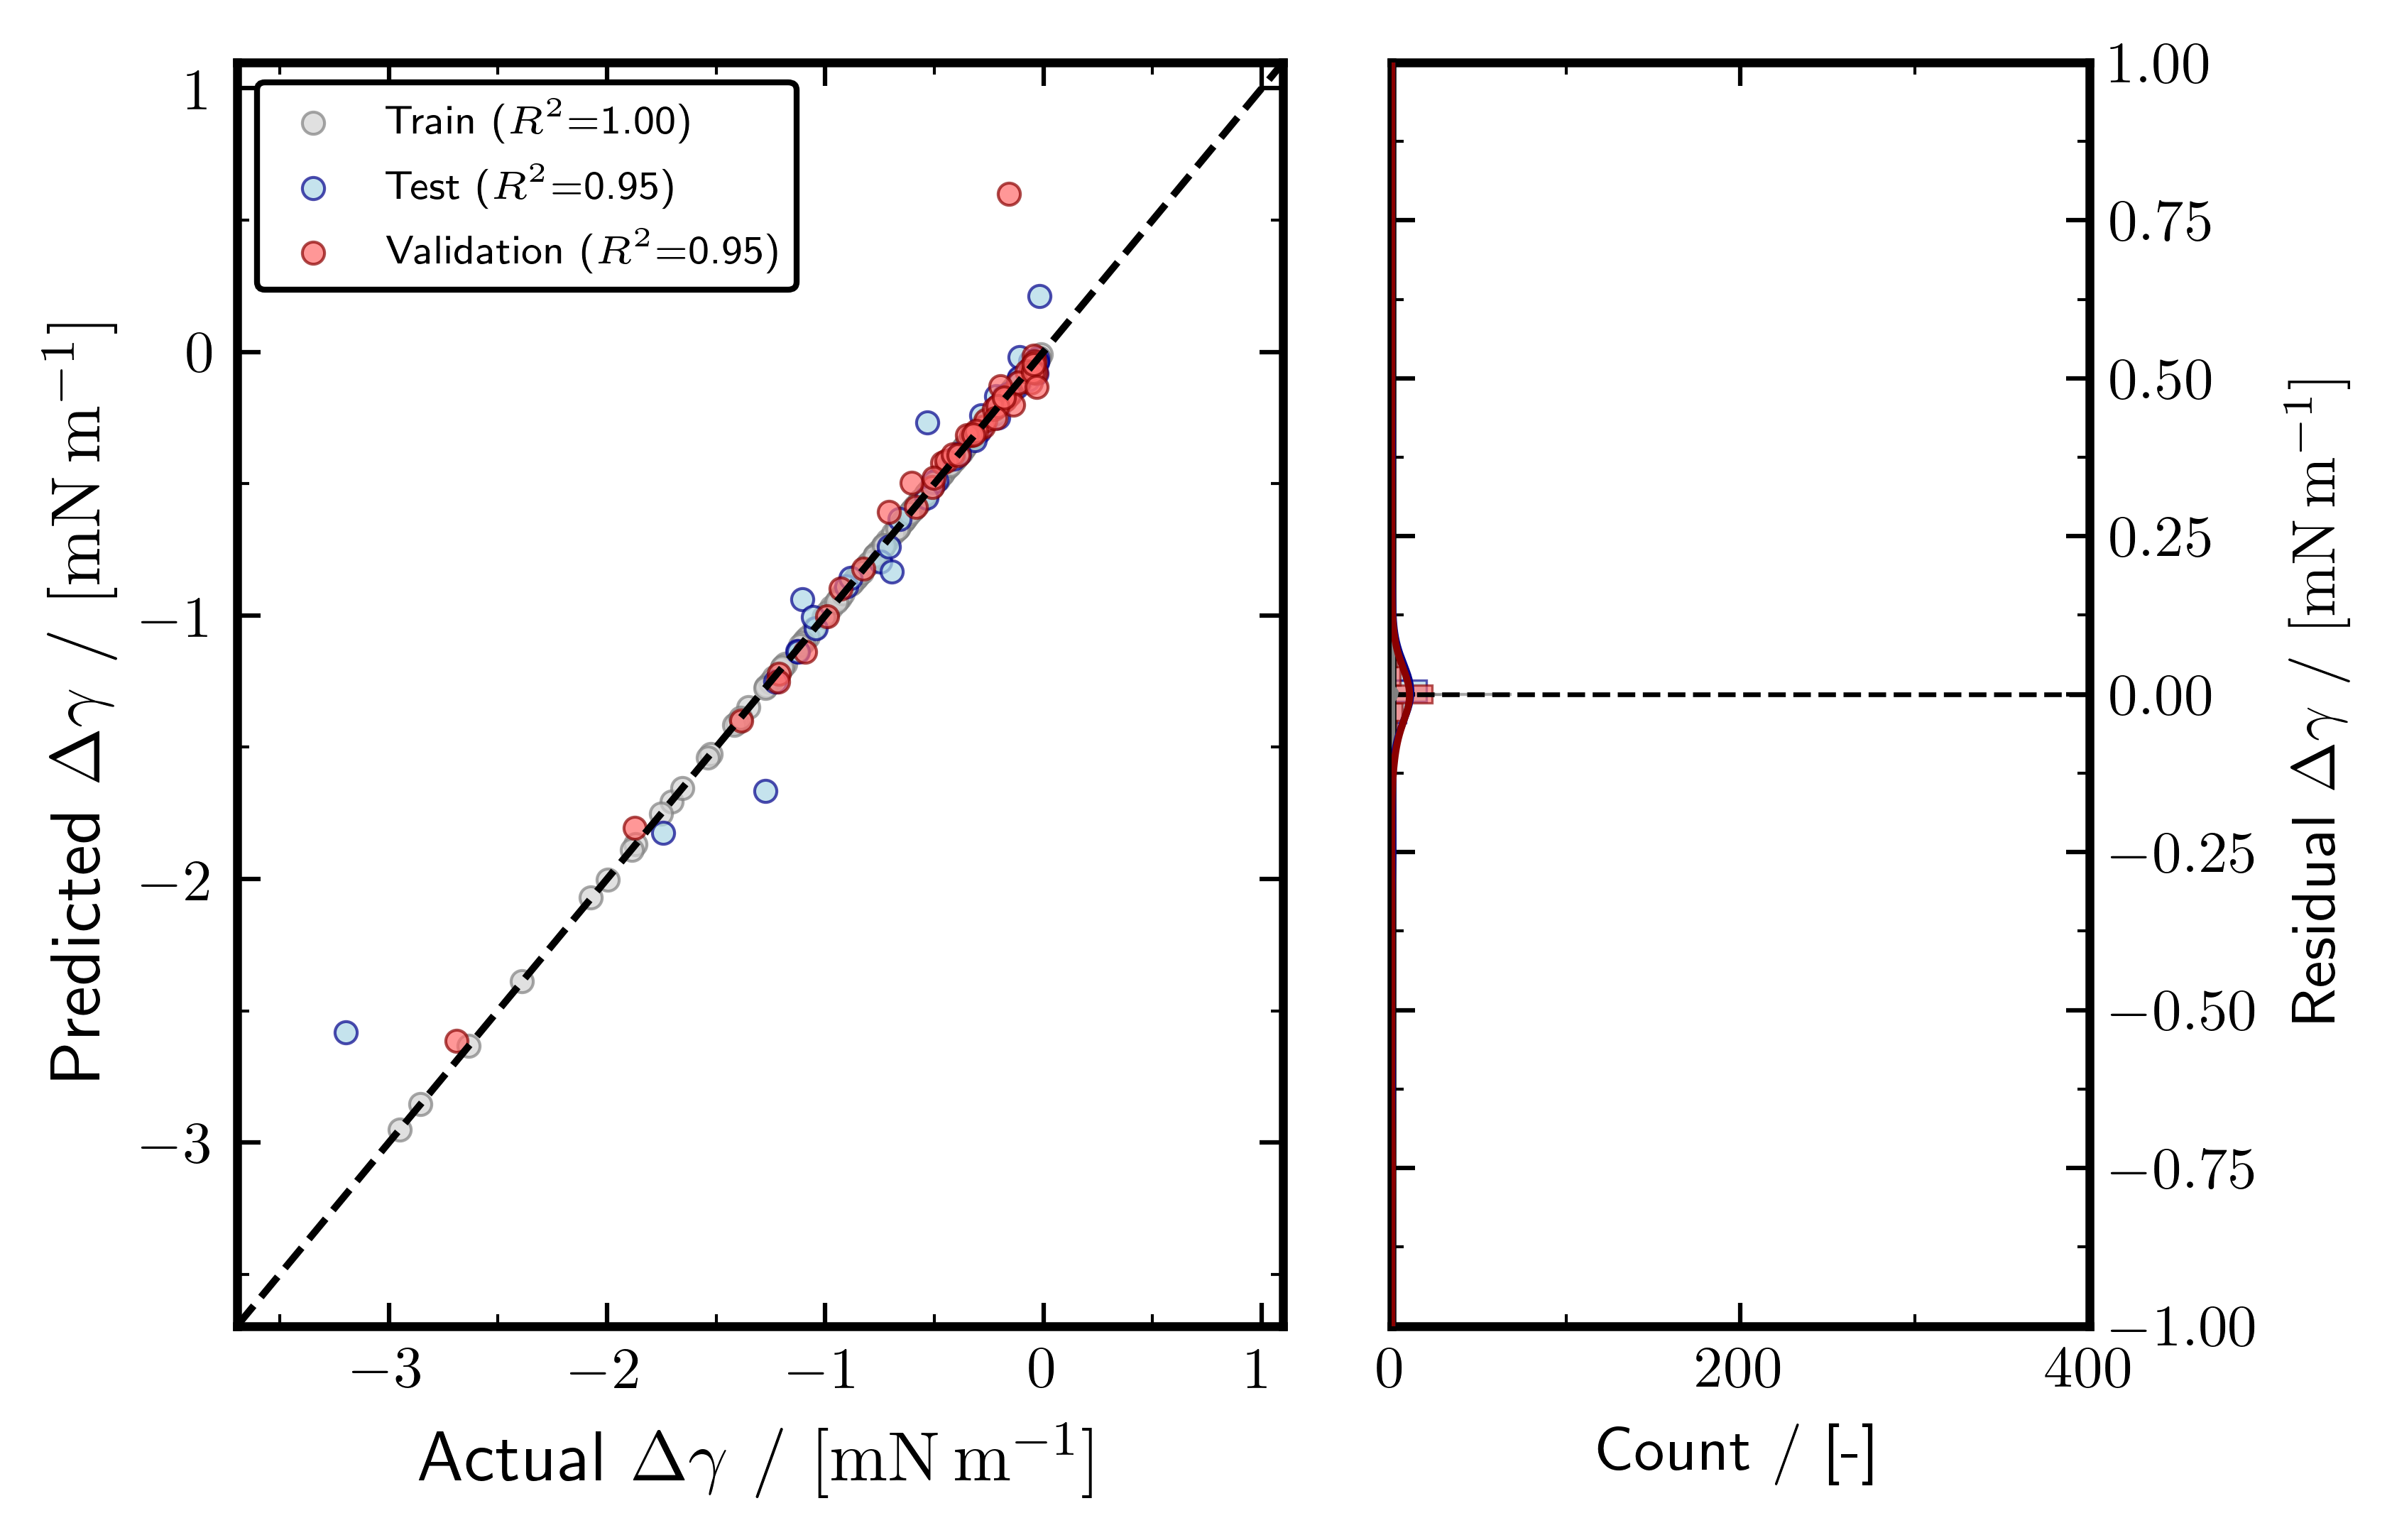

(<Figure size 3300x2100 with 2 Axes>,
 array([<Axes: xlabel='Actual $\\Delta\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$', ylabel='Predicted $\\Delta\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$'>,
        <Axes: xlabel='Count / [-]', ylabel='Residual $\\Delta\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$'>],
       dtype=object))

In [14]:
# Parity + residual distribution (combined two-panel figure)
post.plot_parity_with_residual_distribution(
    n_bins      = 30,
    save_path   = "GPR_parity_residual_distribution",
    folder      = OUTPUT_FOLDER,
)

In [15]:
# ── Validation outlier inspection ────────────────────────────────────────────
N_OUTLIERS = 10

z_cols    = [c for c in features if c.startswith("z_")]
z_non_co2 = [c for c in z_cols if c != "z_carbon_dioxide"]

val_df = X_val.copy()
val_df["y_true"]           = y_val.values
val_df["y_pred"]           = y_val_pred
val_df["error"]            = y_val_pred - y_val.values
val_df["abs_err"]          = val_df["error"].abs()
val_df["source_id"]        = df.loc[val_df.index, "source_id"].values
val_df["dominant_species"] = val_df[z_non_co2].idxmax(axis=1).str.replace("z_", "")

outliers = val_df.nlargest(N_OUTLIERS, "abs_err")[
    ["source_id", "dominant_species", "T", "P", "y_true", "y_pred", "error"]
]

print(f"Top-{N_OUTLIERS} validation outliers (sorted by |error|):")
print(outliers.to_string(index=False))


Top-10 validation outliers (sorted by |error|):
 source_id dominant_species          T         P    y_true    y_pred     error
        50 hydrogen_sulfide 216.646274  5.876138 -0.158464  0.598526  0.756990
        13            argon 208.258920 10.615368 -0.602663 -0.497753  0.104910
         6  carbon_monoxide 218.618068 20.955628 -0.707937 -0.606694  0.101243
        95          methane 222.542295  7.544865 -0.032498 -0.133067 -0.100569
        44         hydrogen 206.177586 79.686773 -2.690828 -2.615162  0.075667
        30          methane 284.426149 56.842397 -0.197131 -0.130976  0.066155
        38         hydrogen 224.694824 66.696627 -1.871482 -1.806359  0.065122
        71 hydrogen_sulfide 220.860912  6.860385 -0.138301 -0.199291 -0.060990
        42         hydrogen 282.342281 50.135288 -0.057959 -0.116937 -0.058978
        40 hydrogen_sulfide 210.451587 37.305930 -1.092046 -1.138725 -0.046679


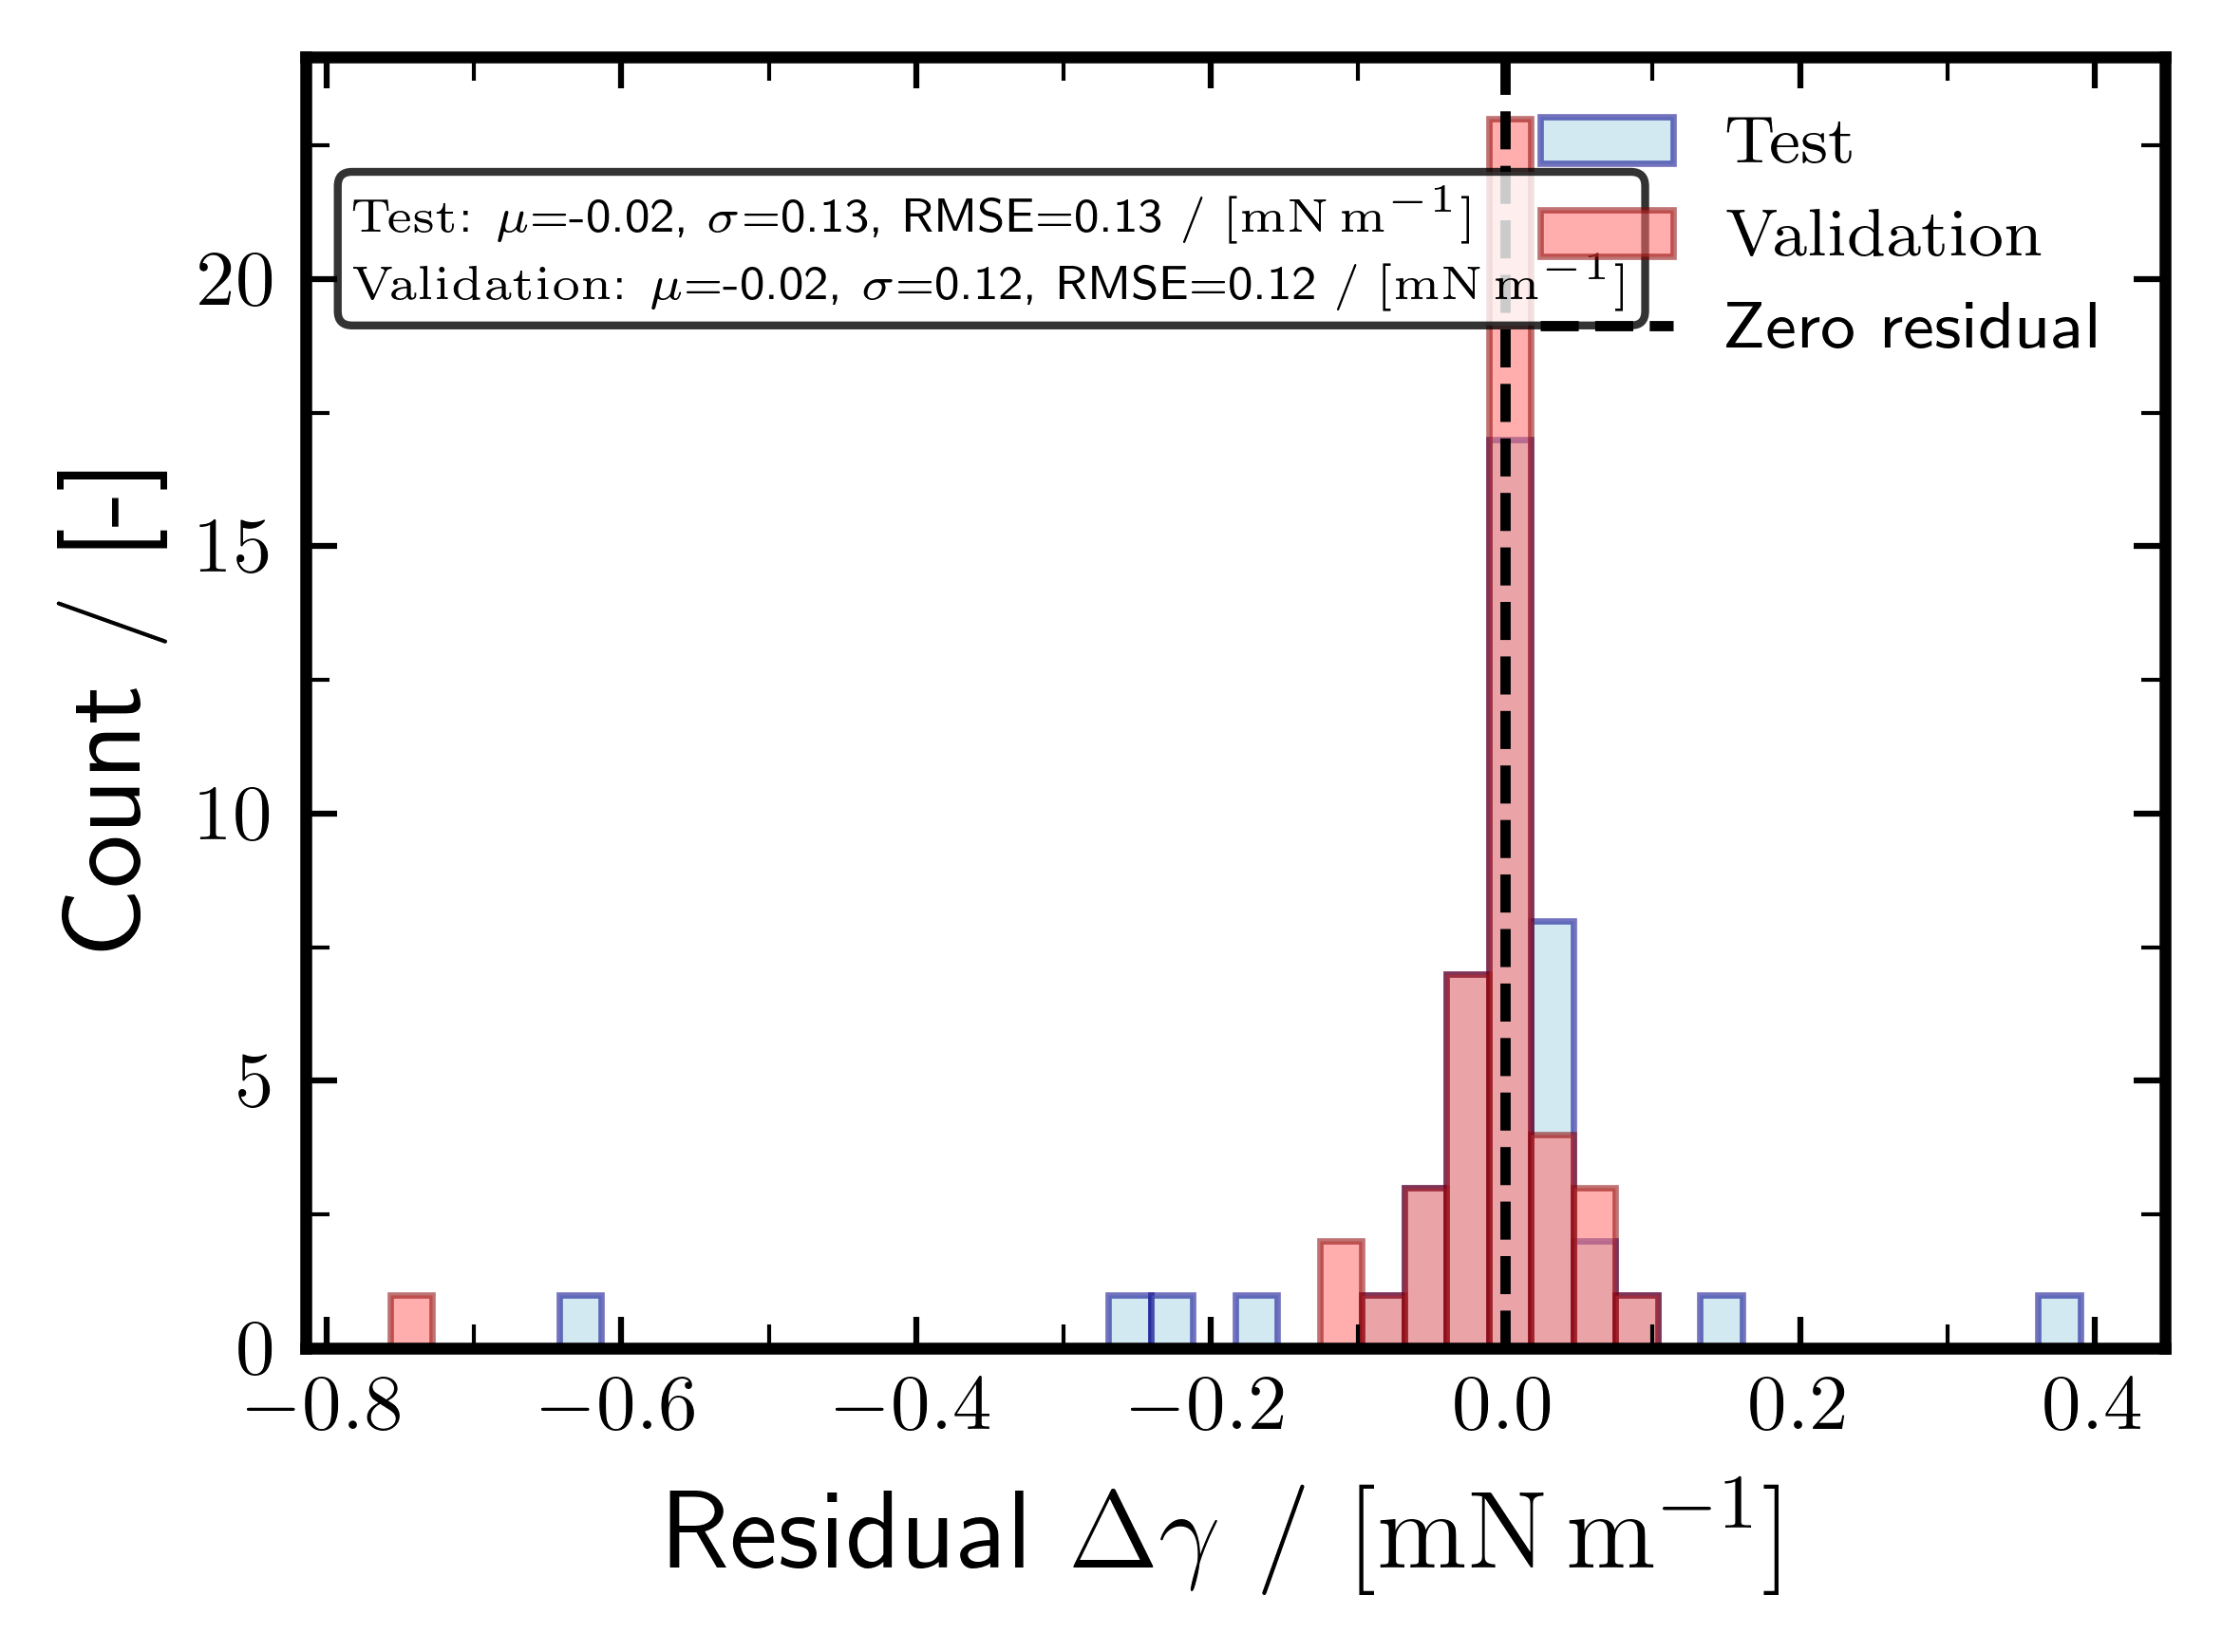

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Residual $\\Delta\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$', ylabel='Count / [-]'>)

In [16]:
# Residual distribution
post.plot_residual_distribution(save_path="GPR_gamma_residual_distribution", folder=OUTPUT_FOLDER)

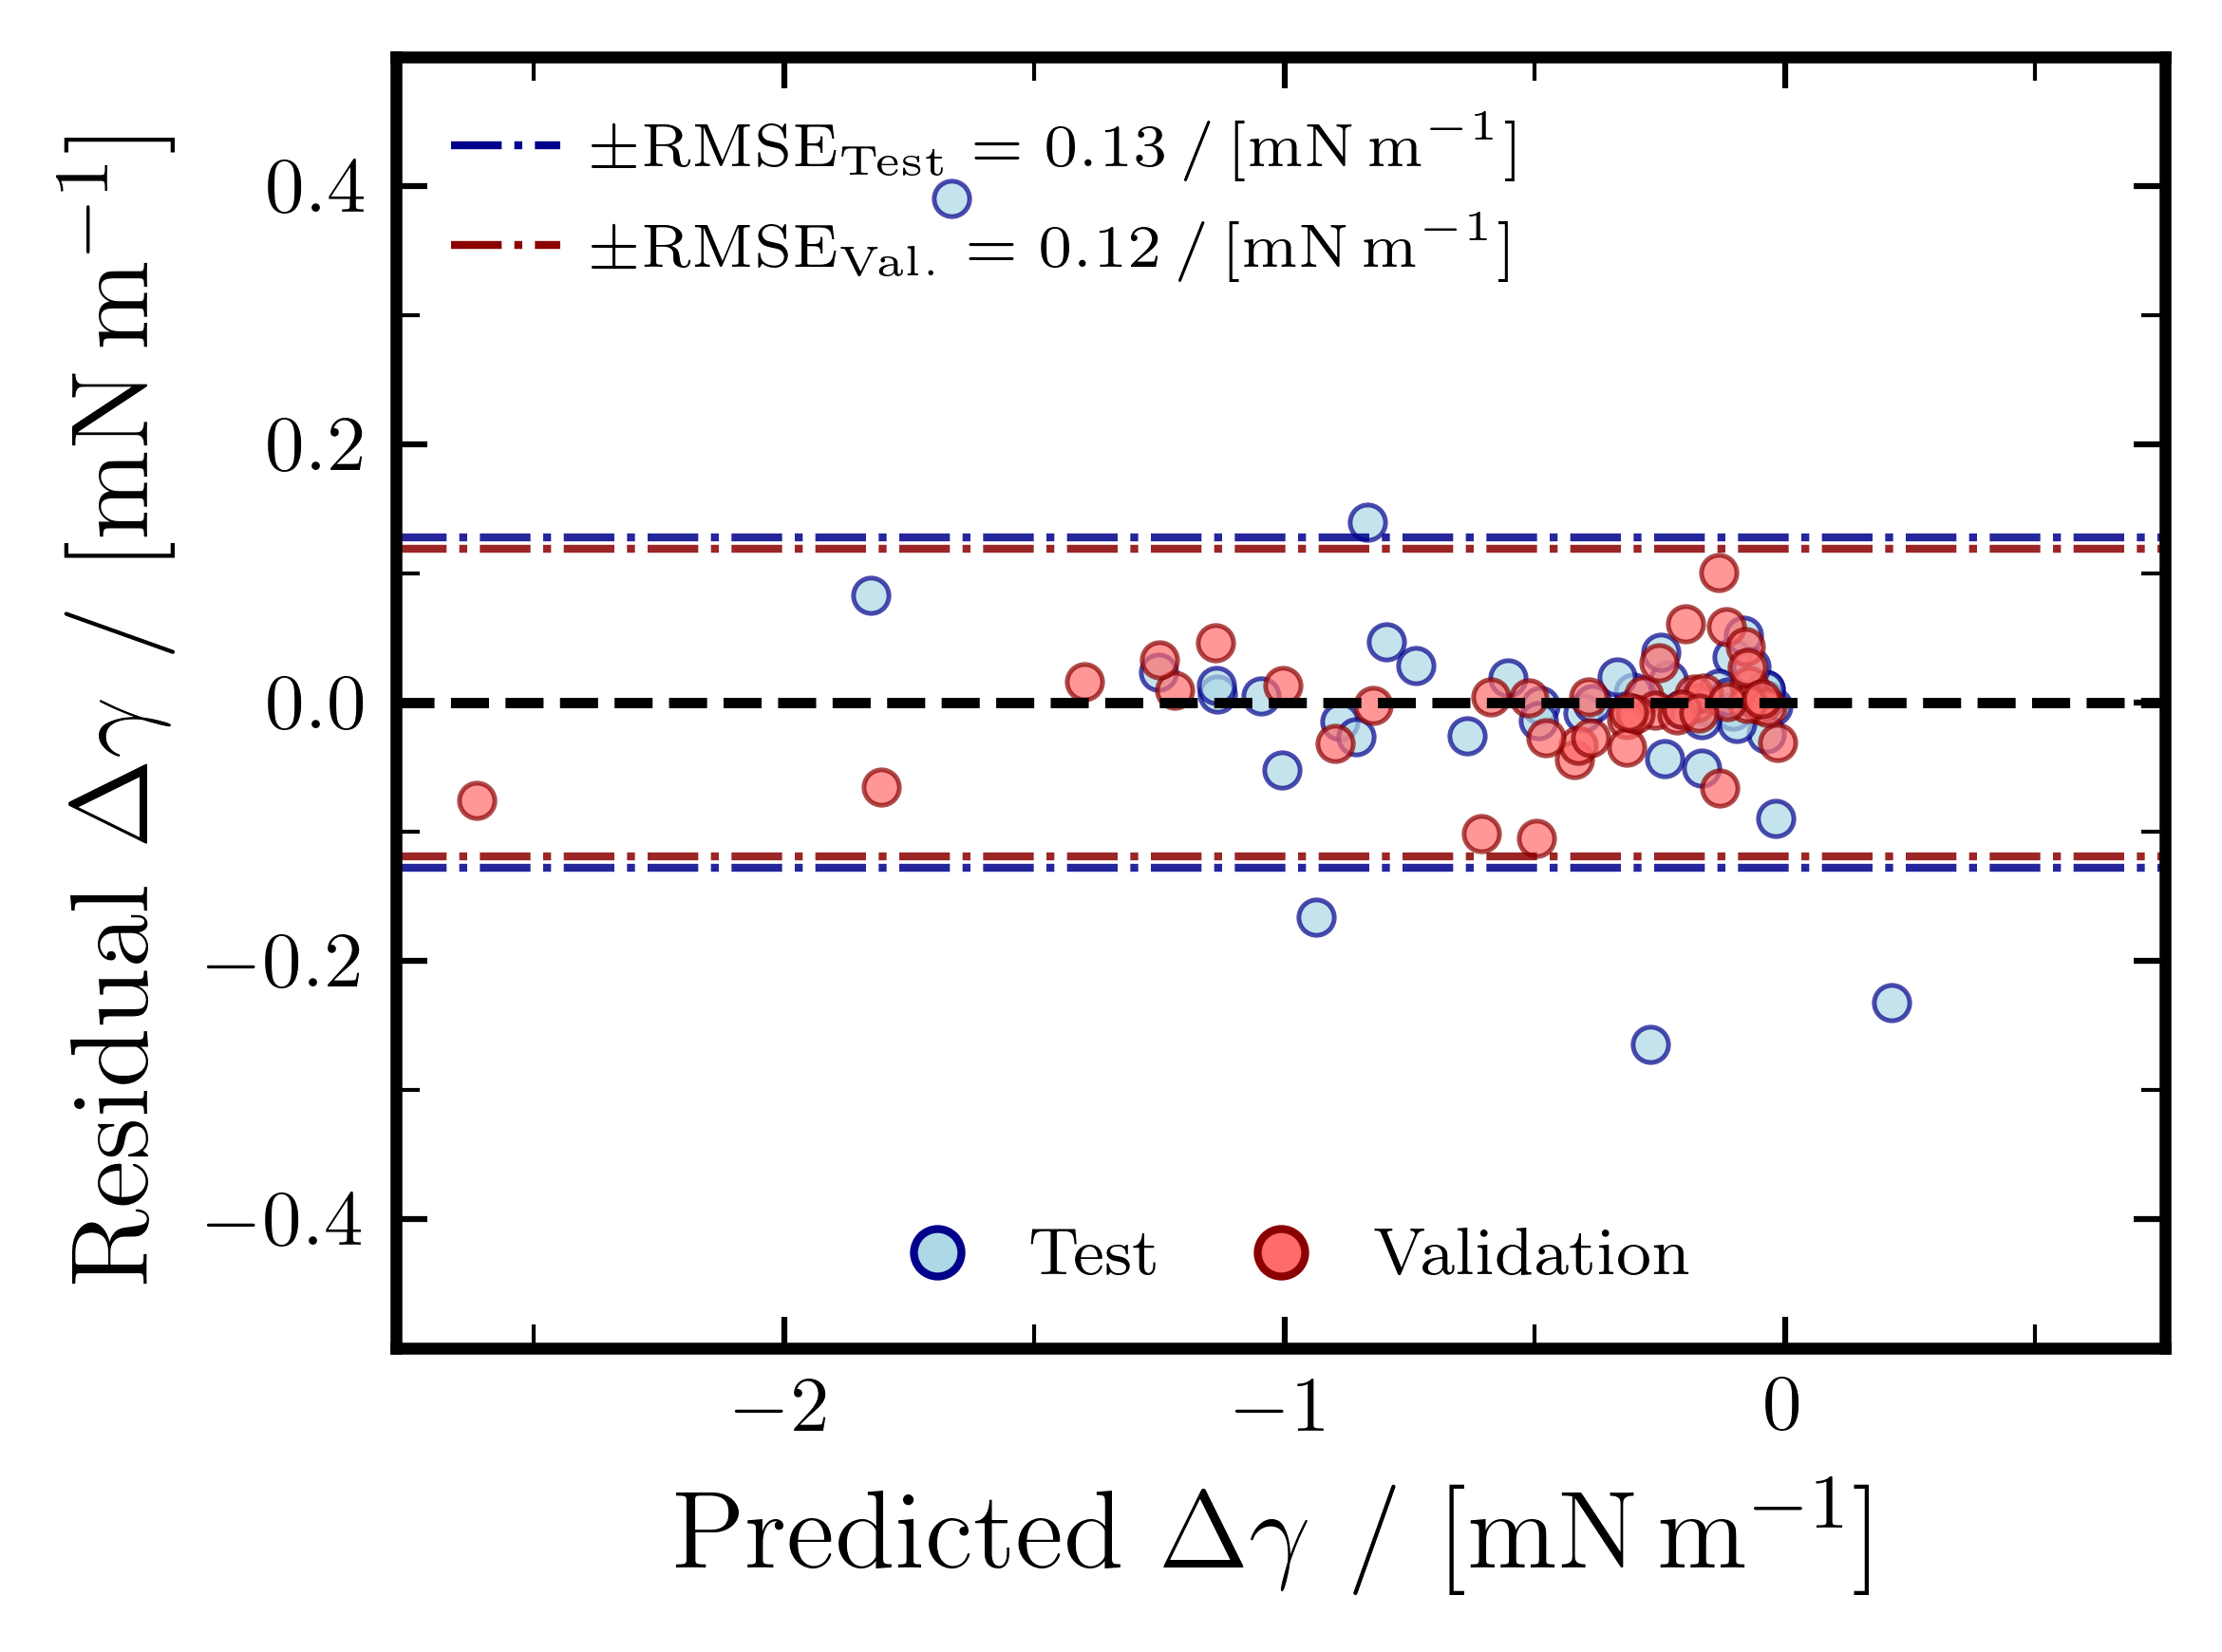

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Predicted}$ $\\Delta\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$', ylabel='$\\mathrm{Residual}$ $\\Delta\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$'>)

In [17]:
# Residuals vs Predicted
post.plot_residual_vs_predicted(save_path="GPR_gamma_residual_vs_predicted", folder=OUTPUT_FOLDER, 
                                y_range= (-0.5, 0.5))

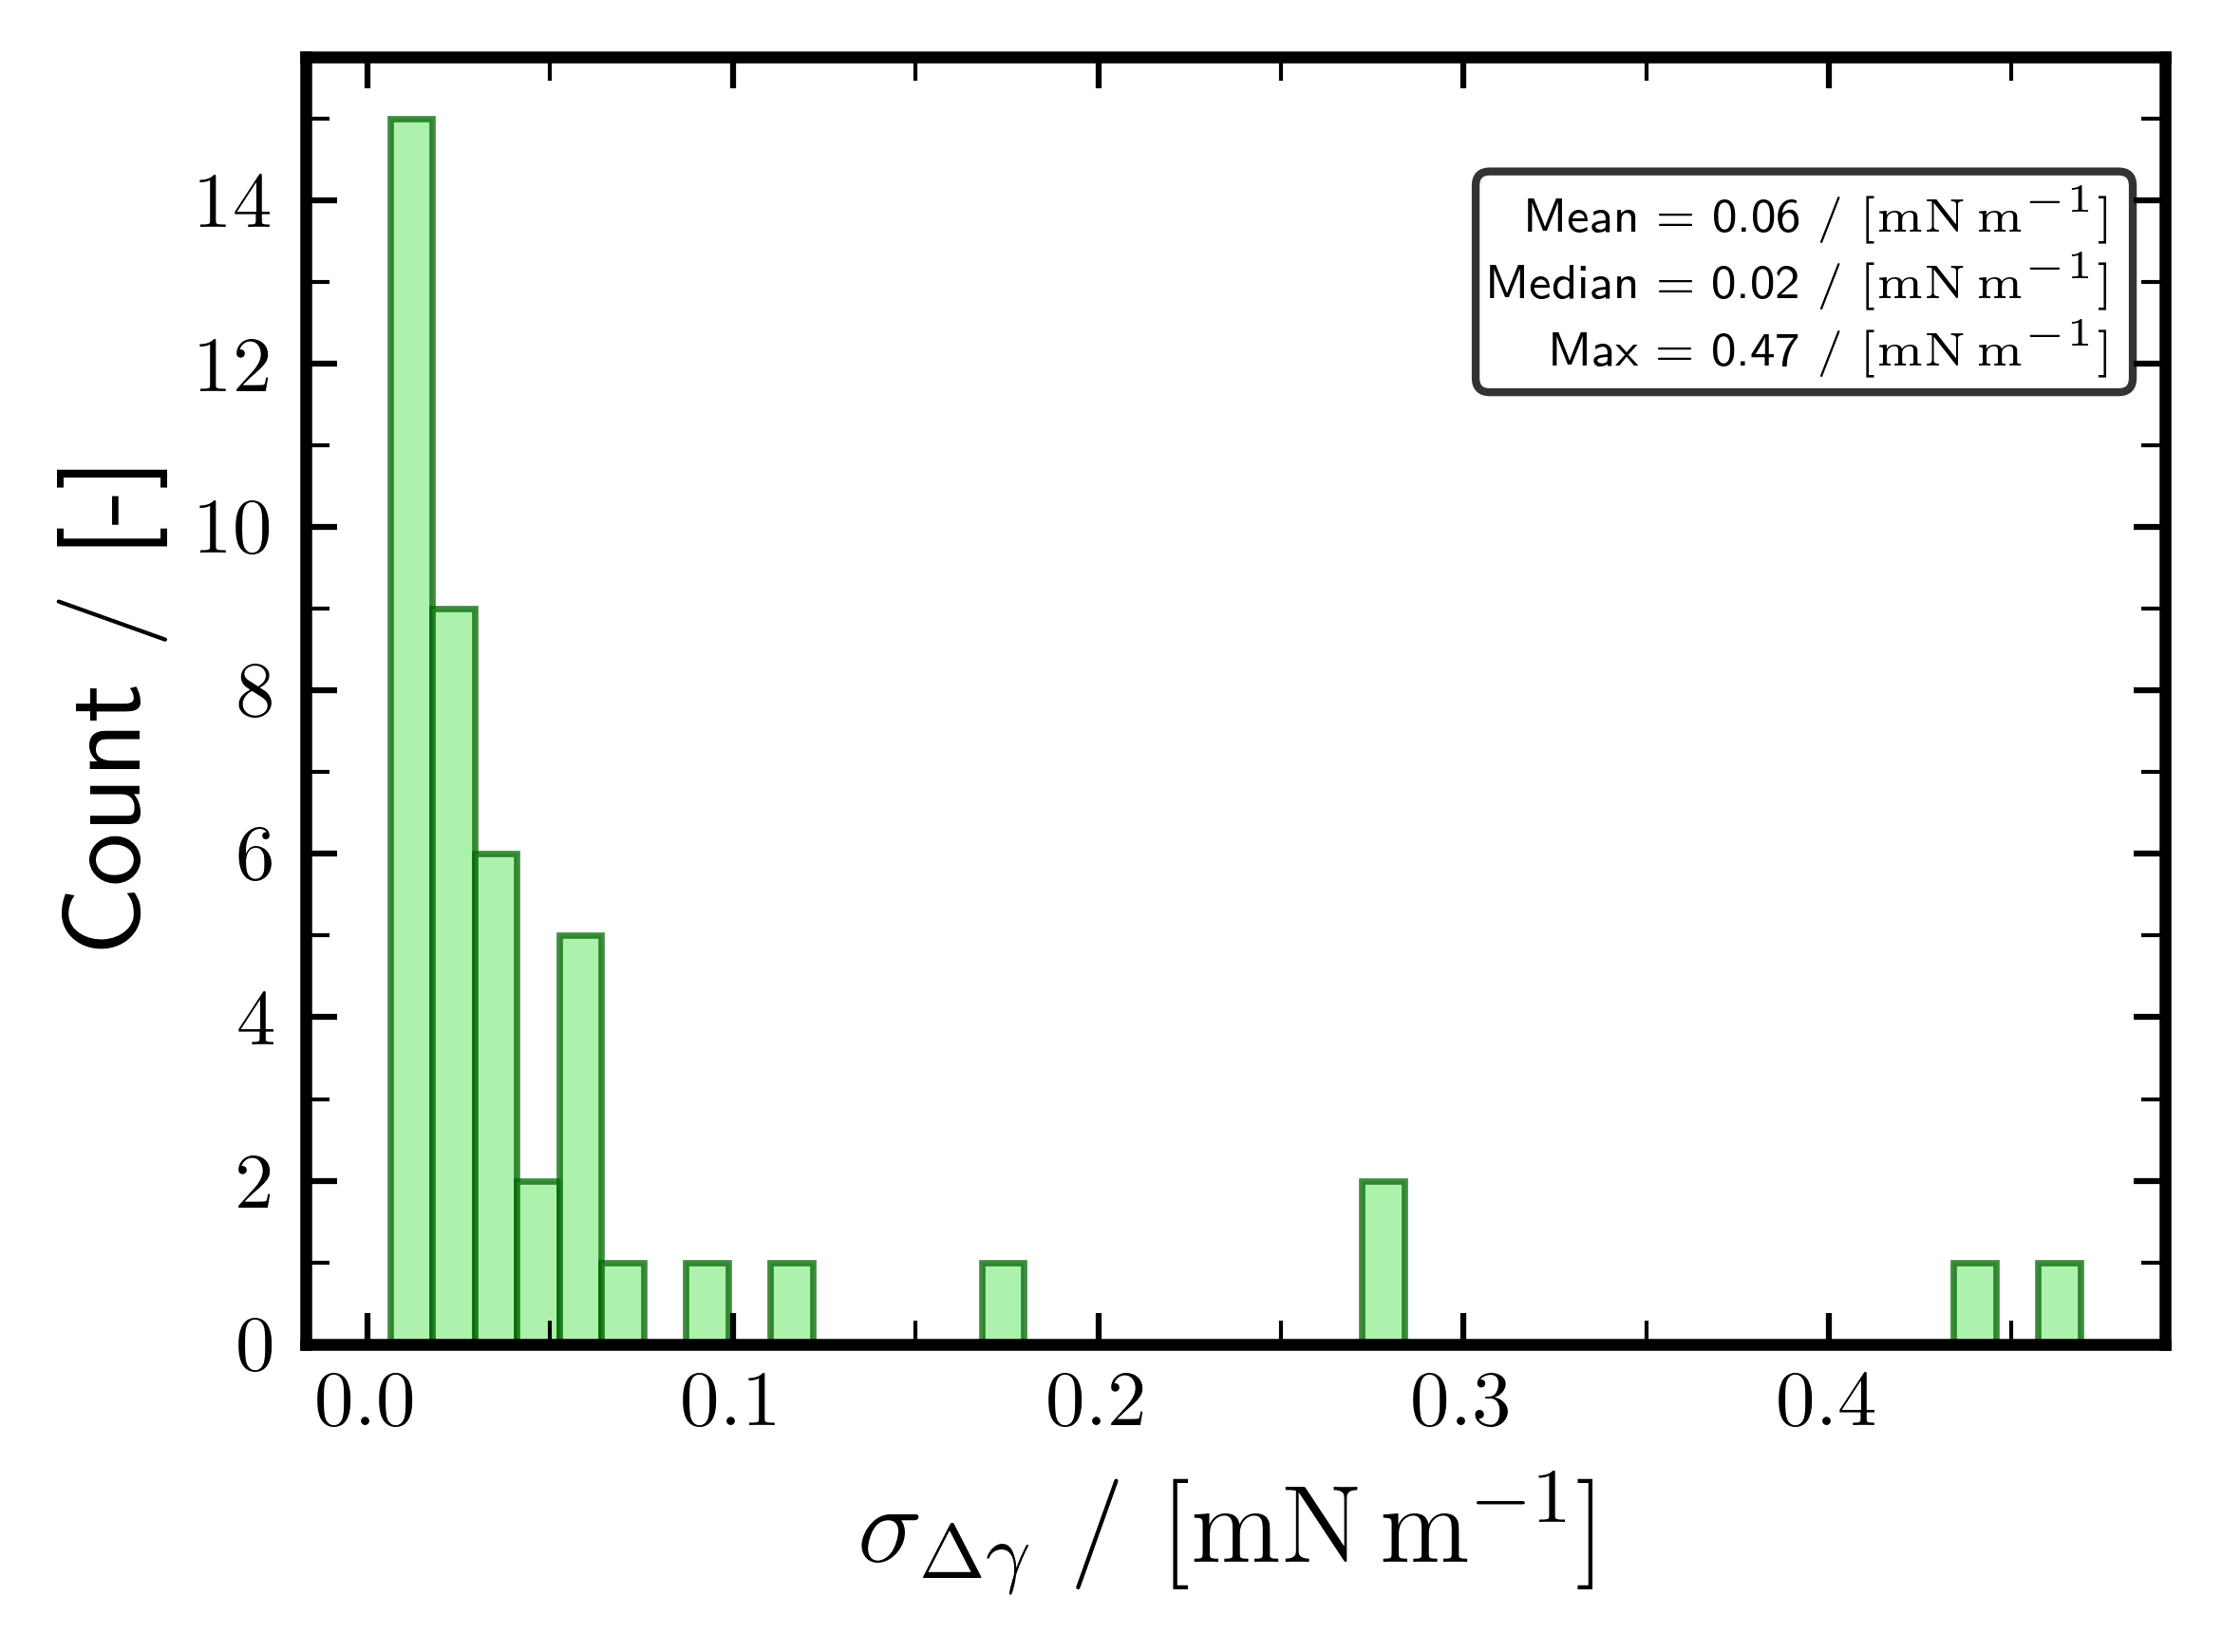

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\sigma_{\\Delta\\gamma}$ / $[\\mathrm{mN\\,m^{-1}}]$', ylabel='Count / [-]'>)

In [18]:
# GPR: Predictive std histogram
post.plot_std_histogram(y_test_std, save_path="GPR_gamma_std_histogram", folder=OUTPUT_FOLDER)

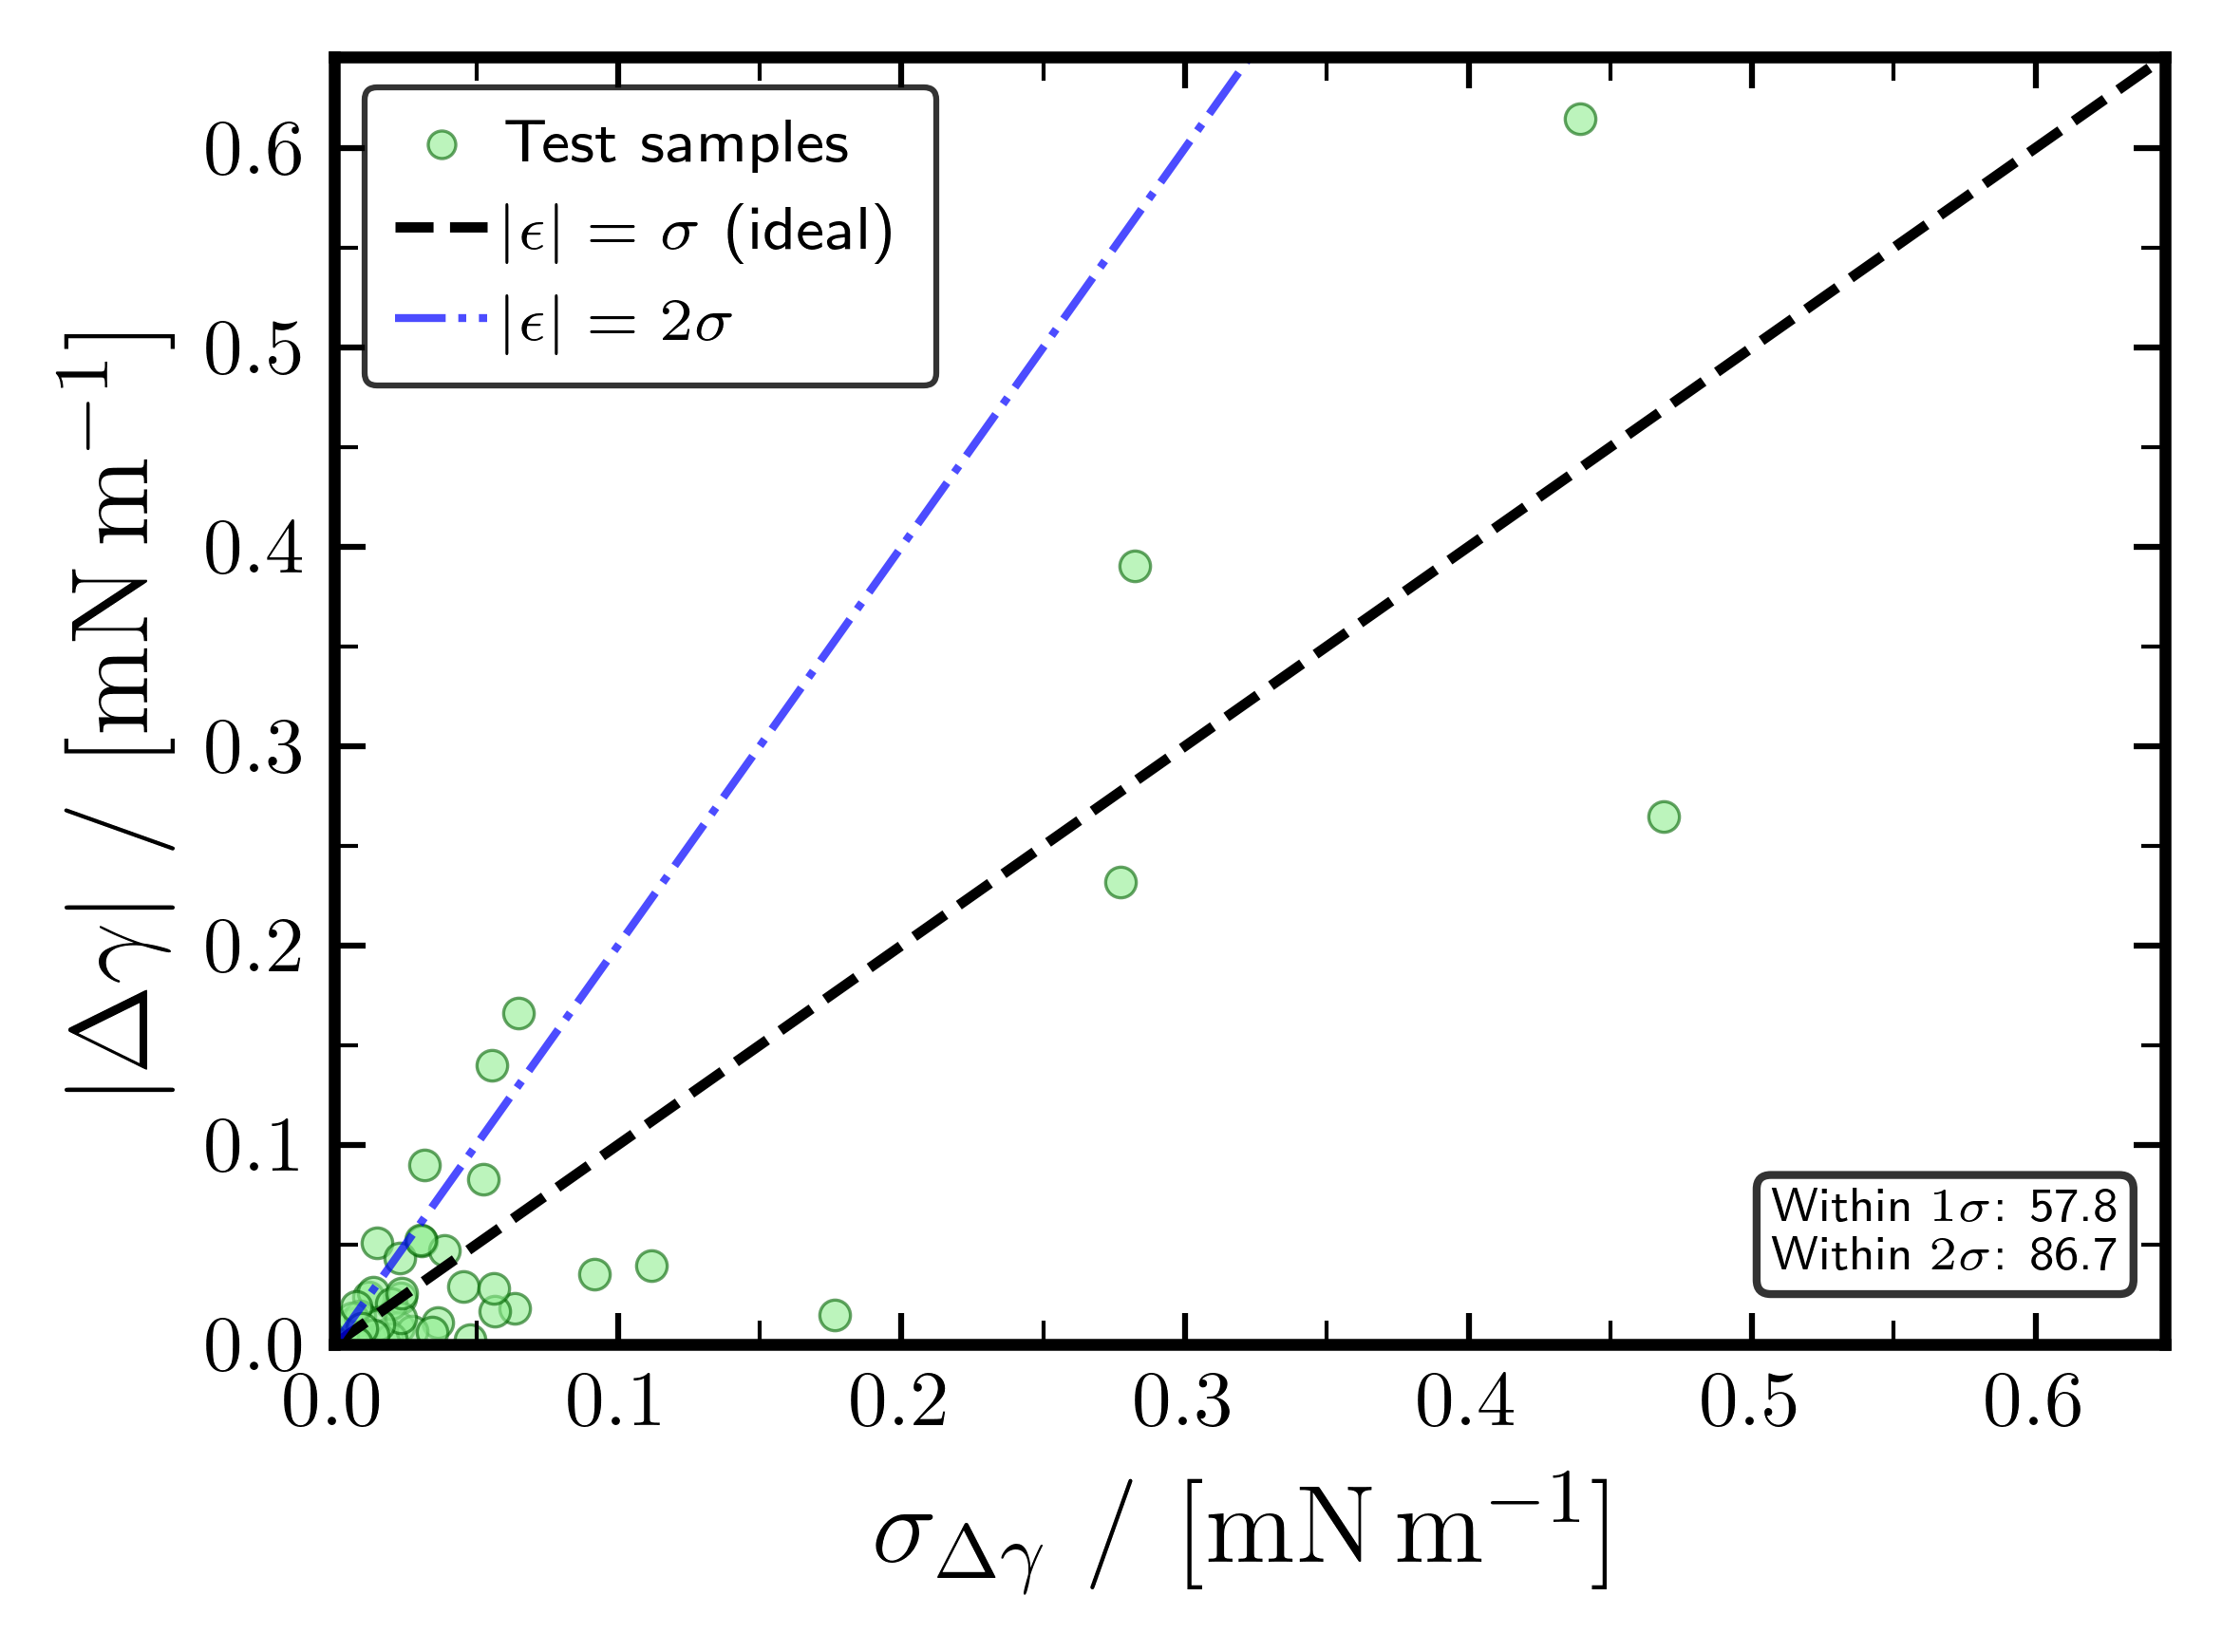

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\sigma_{\\Delta\\gamma}$ / $[\\mathrm{mN\\,m^{-1}}]$', ylabel='$|\\Delta\\gamma|$ / $[\\mathrm{mN\\,m^{-1}}]$'>)

In [19]:
# GPR: |error| vs predictive std (calibration)
post.plot_error_vs_std(y_test_std, save_path="GPR_gamma_error_vs_std", folder=OUTPUT_FOLDER)

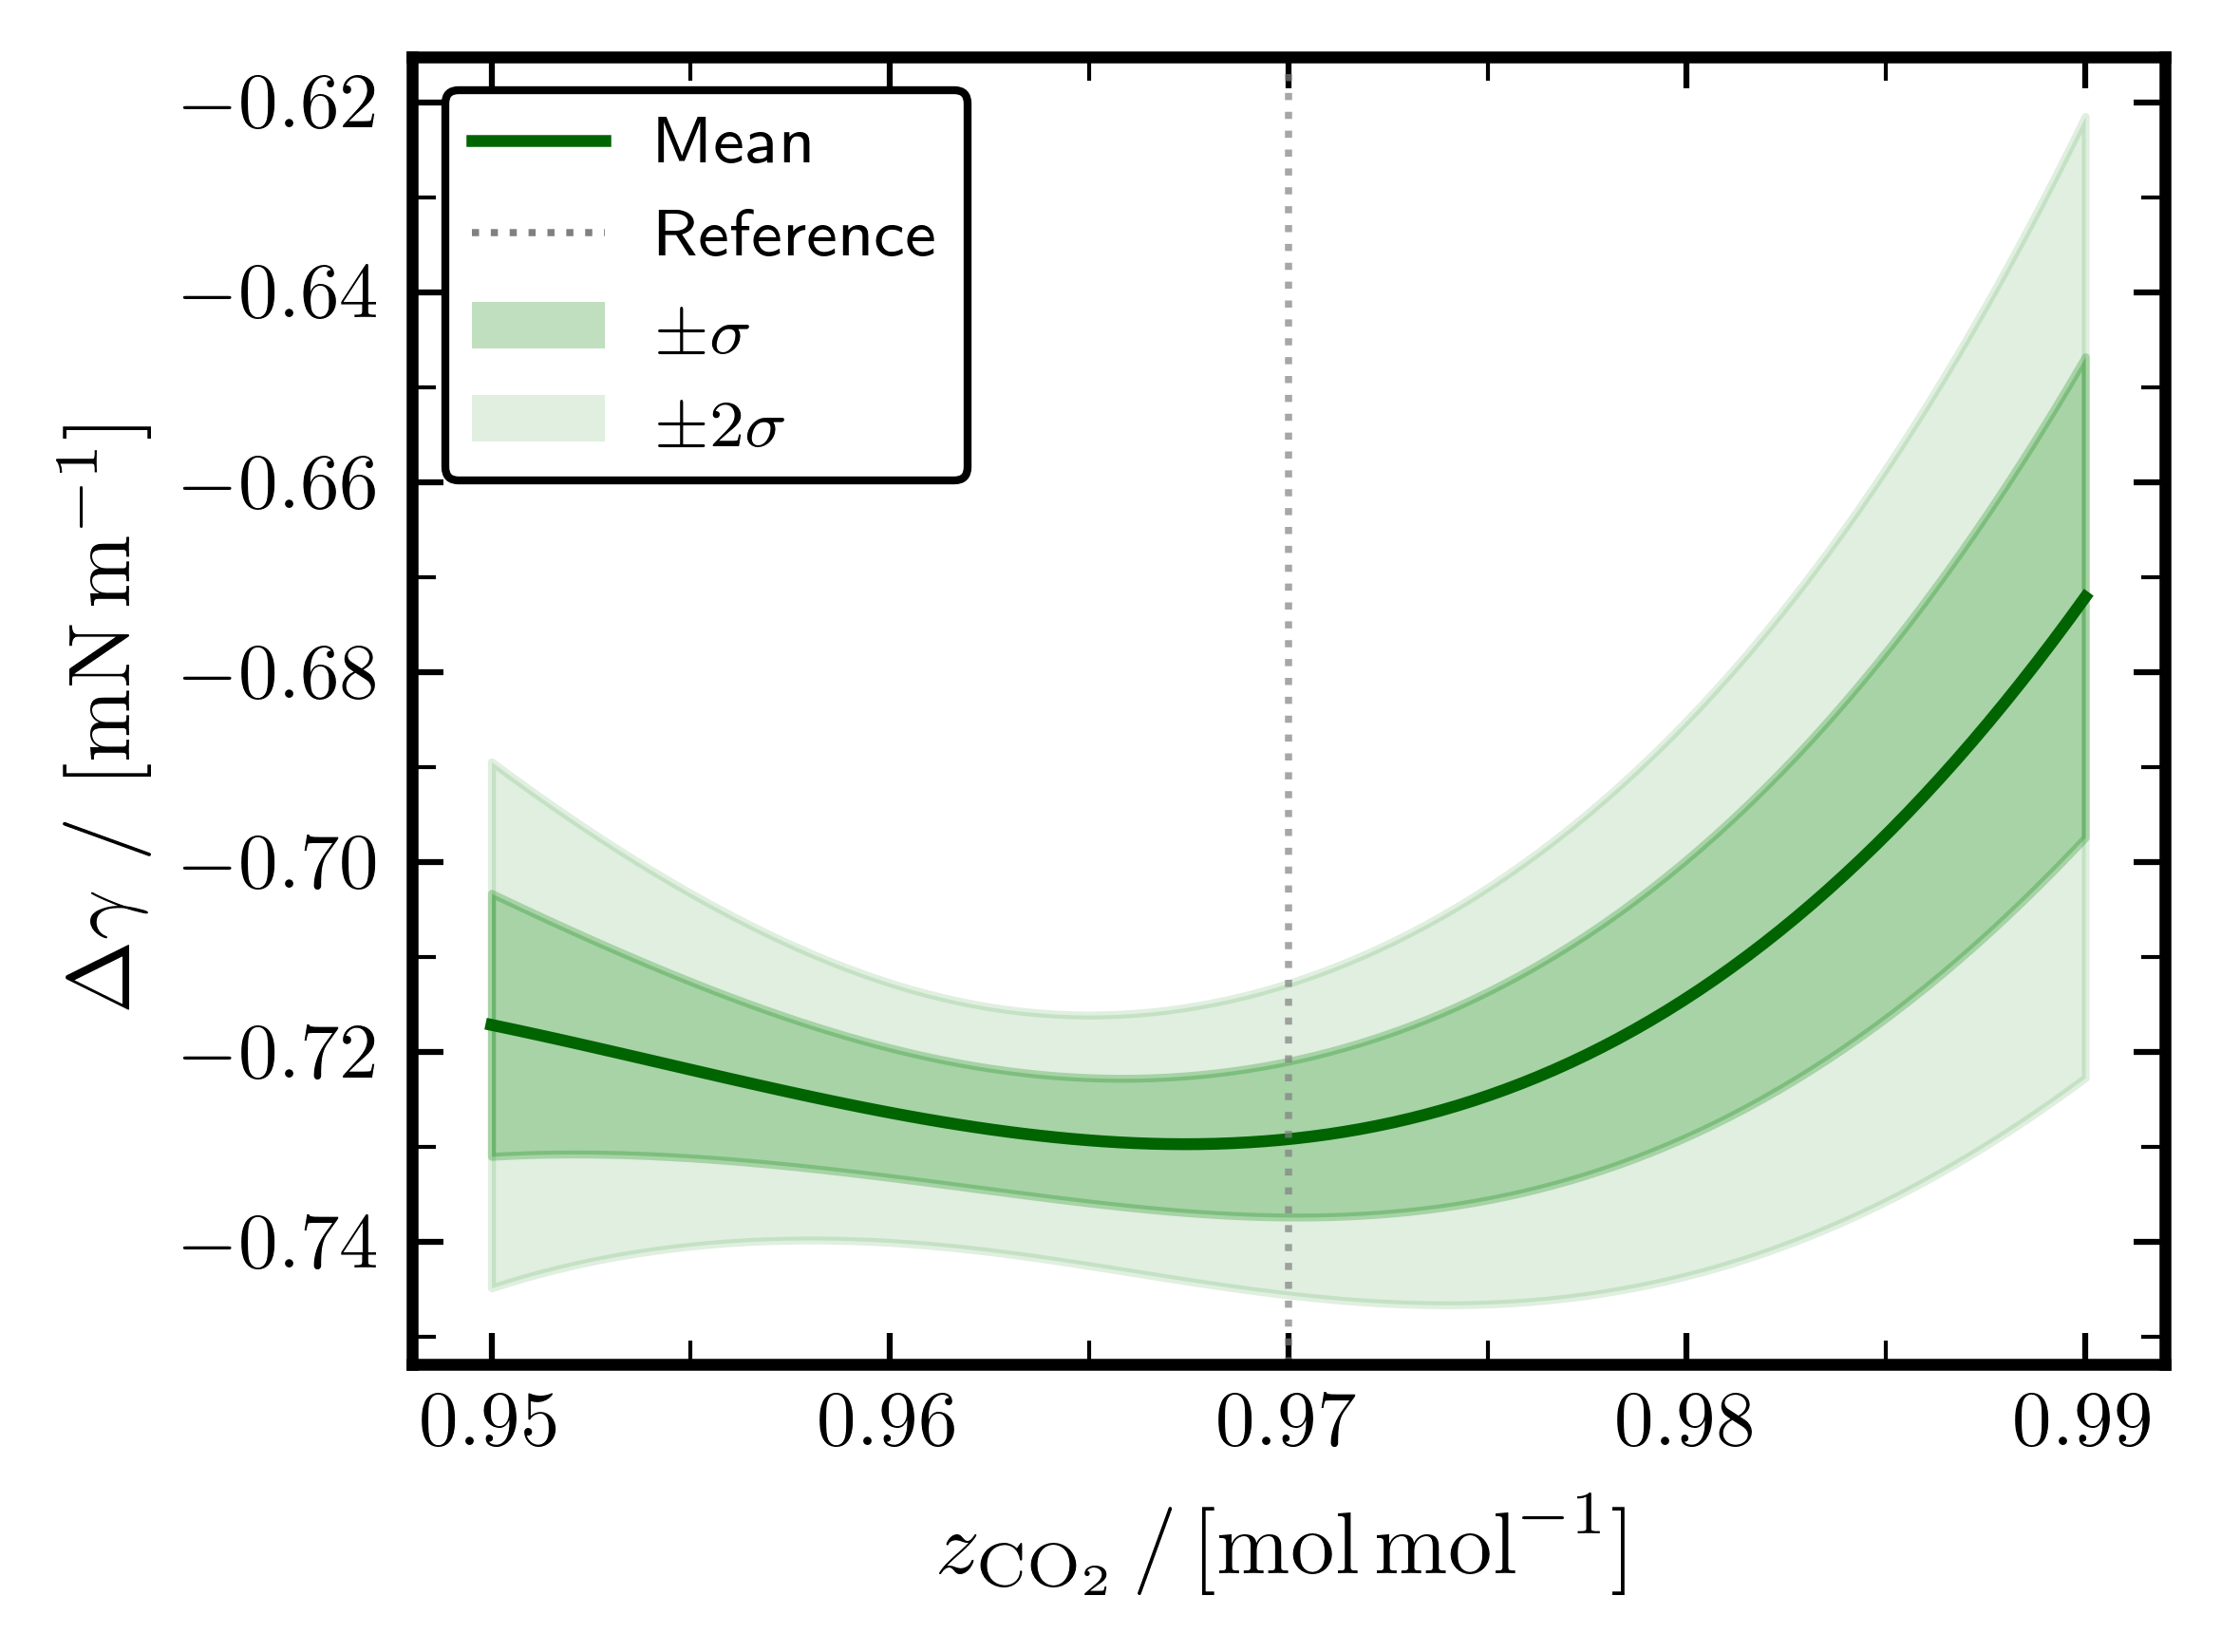

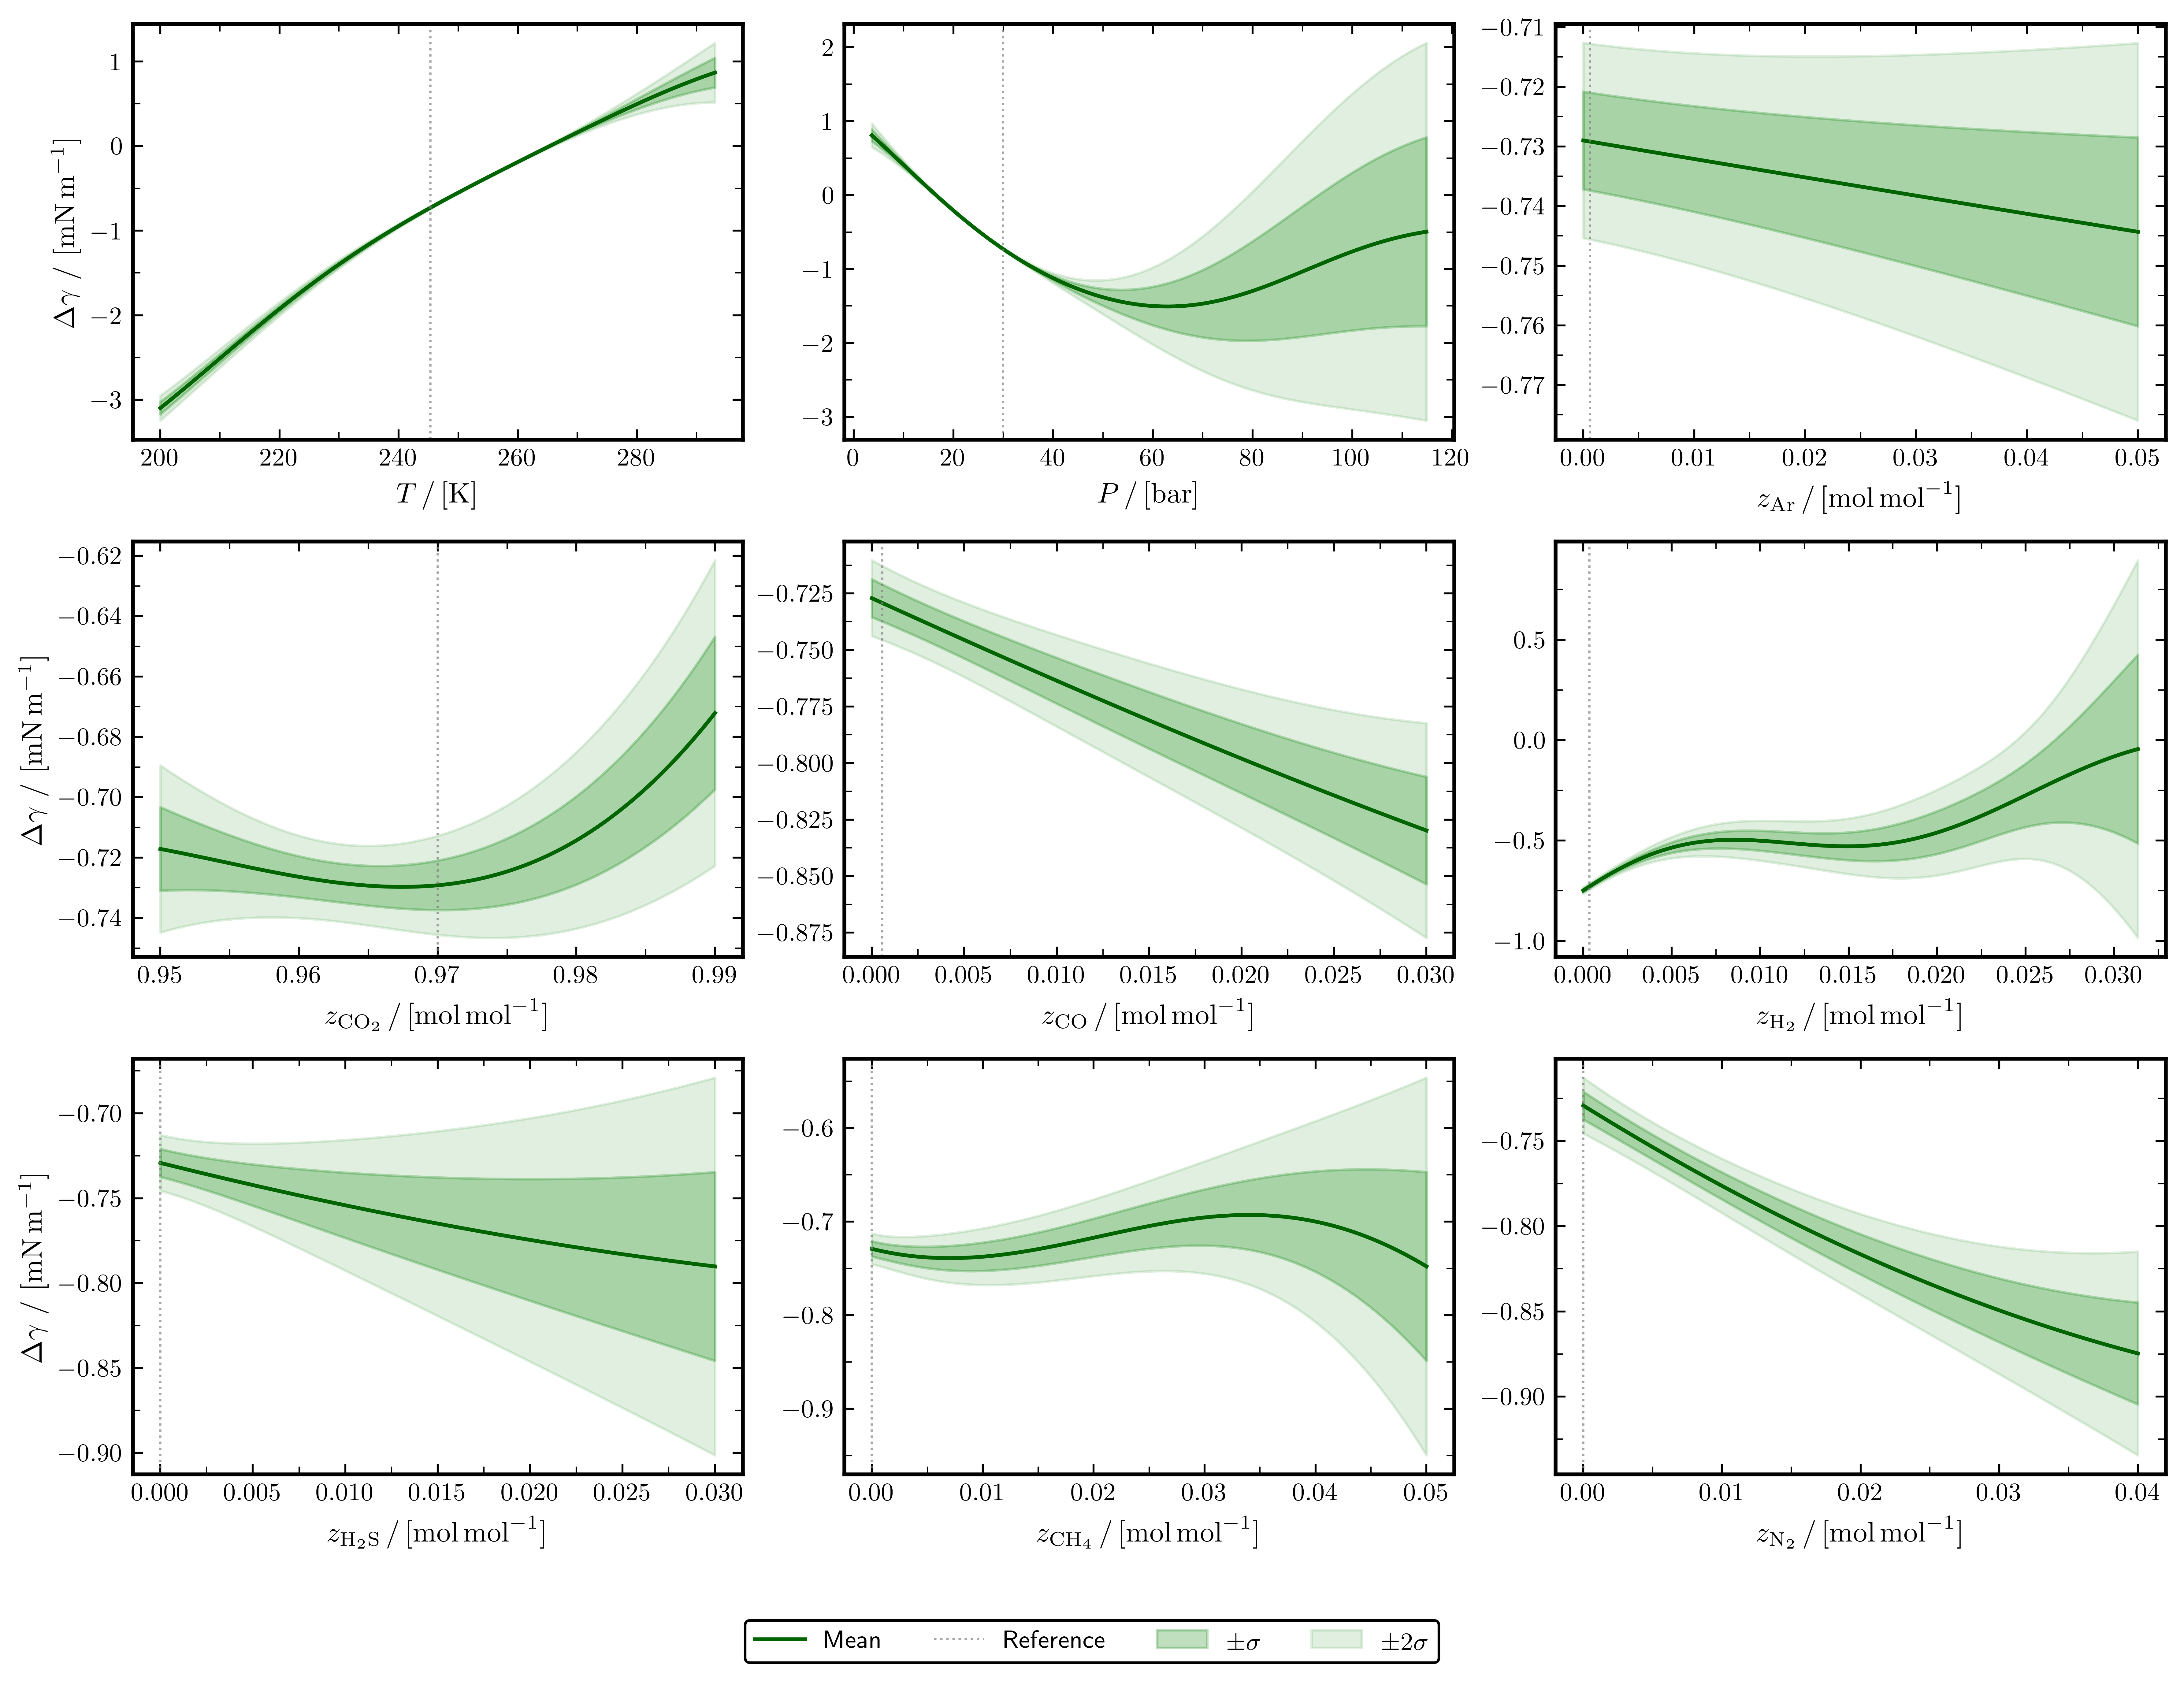

(<Figure size 7200x5400 with 9 Axes>,
 array([<Axes: xlabel='$T \\, / \\, [\\mathrm{K}]$', ylabel='$\\Delta\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$'>,
        <Axes: xlabel='$P \\, / \\, [\\mathrm{bar}]$'>,
        <Axes: xlabel='$z_{\\mathrm{Ar}} \\, / \\, [\\mathrm{mol} \\, \\mathrm{mol}^{-1}]$'>,
        <Axes: xlabel='$z_{\\mathrm{CO_2}} \\, / \\, [\\mathrm{mol} \\, \\mathrm{mol}^{-1}]$', ylabel='$\\Delta\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$'>,
        <Axes: xlabel='$z_{\\mathrm{CO}} \\, / \\, [\\mathrm{mol} \\, \\mathrm{mol}^{-1}]$'>,
        <Axes: xlabel='$z_{\\mathrm{H_2}} \\, / \\, [\\mathrm{mol} \\, \\mathrm{mol}^{-1}]$'>,
        <Axes: xlabel='$z_{\\mathrm{H_2S}} \\, / \\, [\\mathrm{mol} \\, \\mathrm{mol}^{-1}]$', ylabel='$\\Delta\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$'>,
        <Axes: xlabel='$z_{\\mathrm{CH_4}} \\, / \\, [\\mathrm{mol} \\, \\mathrm{mol}^{-1}]$'>,
        <Axes: xlabel='$z_{\\mathrm{N_2}} \\, / \\, [\\mathrm{mol} \\, \\mathrm{mol}^{-1}]$'>],
       dtype=object)

In [21]:
# GPR: Response curves — saved individually per feature
X_ref = X_train.median().values
post.plot_response_curves(
    model               = gpr_model,
    X_ref               = X_ref,
    feature_names       = features,
    X_train             = X_train,
    n_points            = 100,
    return_std          = True,
    save_individually   = True,
    save_path           = "GPR_gamma_response",
    folder              = OUTPUT_FOLDER,
)

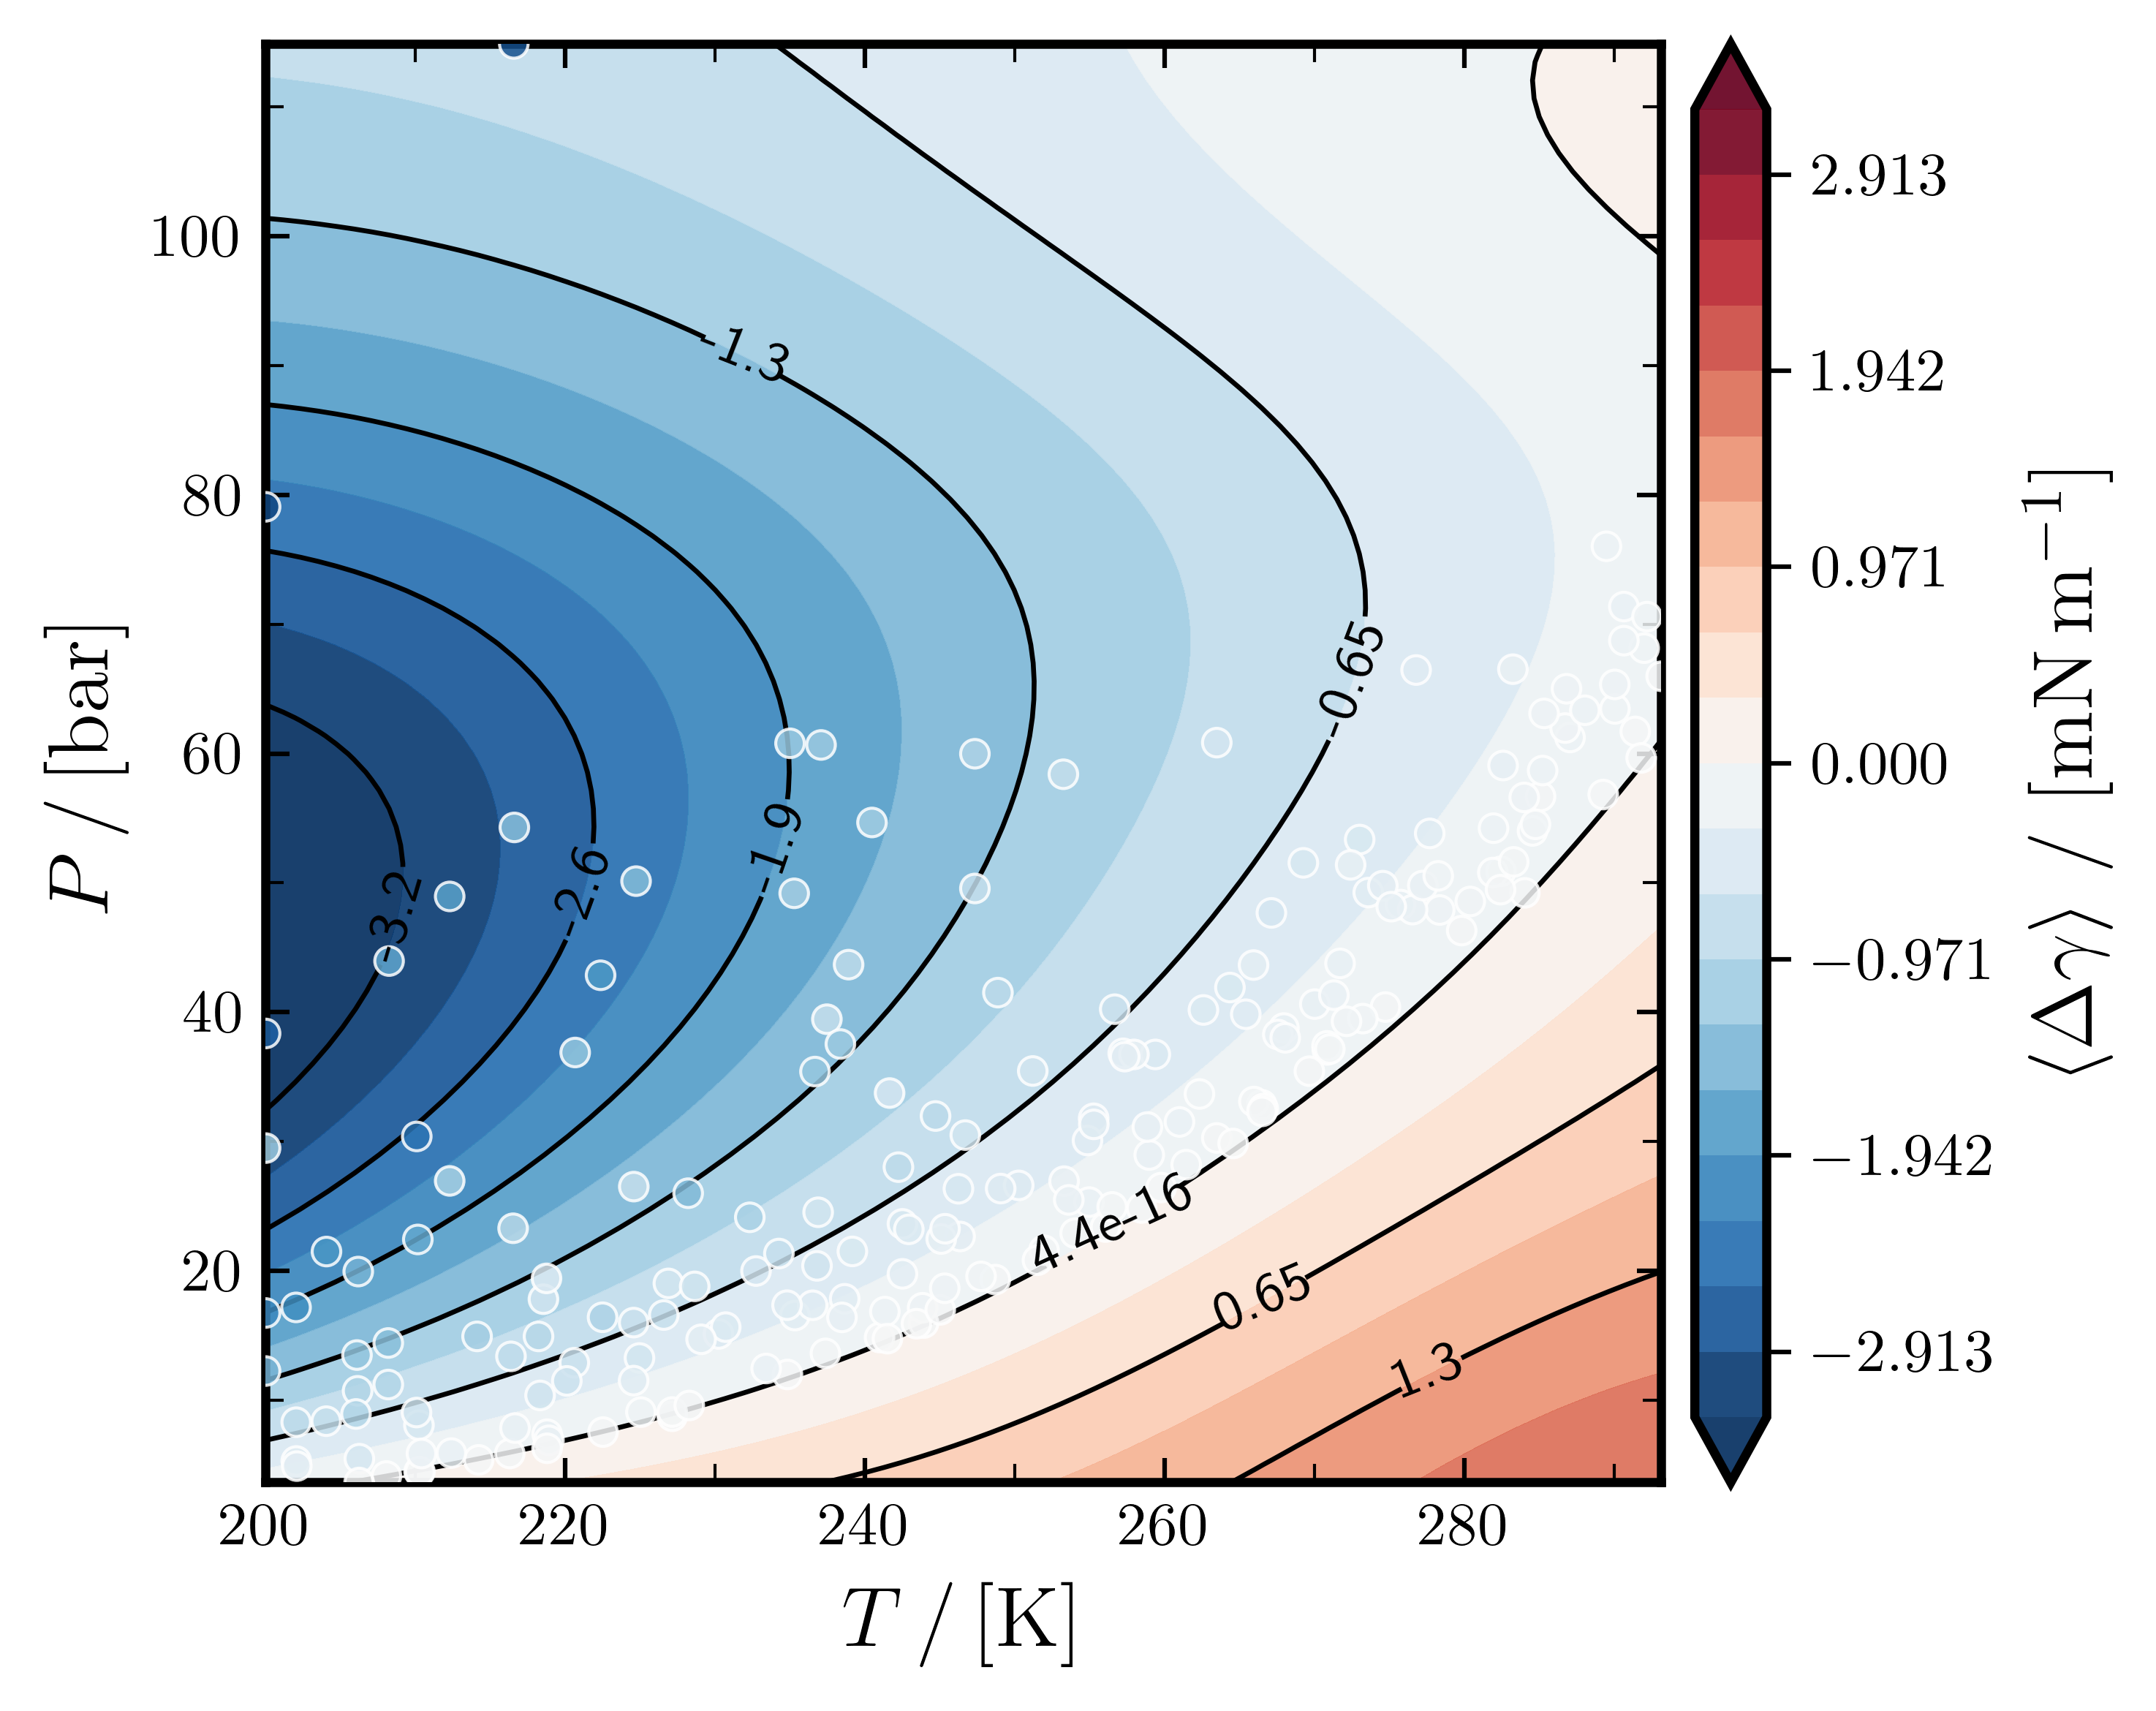

(<Figure size 3000x2400 with 2 Axes>,
 array([<Axes: xlabel='$T \\, / \\, [\\mathrm{K}]$', ylabel='$P \\, / \\, [\\mathrm{bar}]$'>],
       dtype=object))

In [22]:
# 2D Response Surface: T vs P (all z_* fixed at training median)
post.plot_2d_response_surface(
    model         = gpr_model,
    X_train       = X_train,
    y_train       = y_train,
    feature_names = features,
    T_name        = "T",
    P_name        = "P",
    n_grid        = 80,
    return_std    = False,
    save_path     = "GPR_2D_response_T_P",
    folder        = OUTPUT_FOLDER,
)

In [23]:
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
model_path = os.path.join(OUTPUT_FOLDER, "GPR_residual_model.joblib")
joblib.dump(gpr_model, model_path)
print(f"Model saved to: {model_path}")

Model saved to: GPR_RESIDUAL_OUTPUTS/GPR_residual_model.joblib


In [24]:
# Reconstruct full gamma_cDFT = gamma_base + residual_pred

gamma_base_train = df.loc[X_train.index, "gamma_base"].values
gamma_base_test  = df.loc[X_test.index,  "gamma_base"].values
gamma_base_val   = df.loc[X_val.index,   "gamma_base"].values

gamma_cDFT_train = df.loc[X_train.index, "gamma_cDFT"].values
gamma_cDFT_test  = df.loc[X_test.index,  "gamma_cDFT"].values
gamma_cDFT_val   = df.loc[X_val.index,   "gamma_cDFT"].values

gamma_pred_train = gamma_base_train + y_train_pred
gamma_pred_test  = gamma_base_test  + y_test_pred
gamma_pred_val   = gamma_base_val   + y_val_pred

# std carries through the additive reconstruction unchanged
gamma_cDFT_r2_train  = _r2(gamma_cDFT_train, gamma_pred_train)
gamma_cDFT_r2_test   = _r2(gamma_cDFT_test,  gamma_pred_test)
gamma_cDFT_r2_val    = _r2(gamma_cDFT_val,   gamma_pred_val)
gamma_cDFT_mae_train = _mae(gamma_cDFT_train, gamma_pred_train)
gamma_cDFT_mae_test  = _mae(gamma_cDFT_test,  gamma_pred_test)
gamma_cDFT_mae_val   = _mae(gamma_cDFT_val,   gamma_pred_val)

print(f"Reconstructed gamma_cDFT  R² — train: {gamma_cDFT_r2_train:.4f} "
      f"| test: {gamma_cDFT_r2_test:.4f} "
      f"| val:  {gamma_cDFT_r2_val:.4f}")
print(f"Reconstructed gamma_cDFT MAE [mN/m] — train: {gamma_cDFT_mae_train:.6f} "
      f"| test: {gamma_cDFT_mae_test:.6f} "
      f"| val: {gamma_cDFT_mae_val:.6f}")

Reconstructed gamma_cDFT  R² — train: 1.0000 | test: 0.9996 | val:  0.9996
Reconstructed gamma_cDFT MAE [mN/m] — train: 0.000873 | test: 0.059430 | val: 0.043443


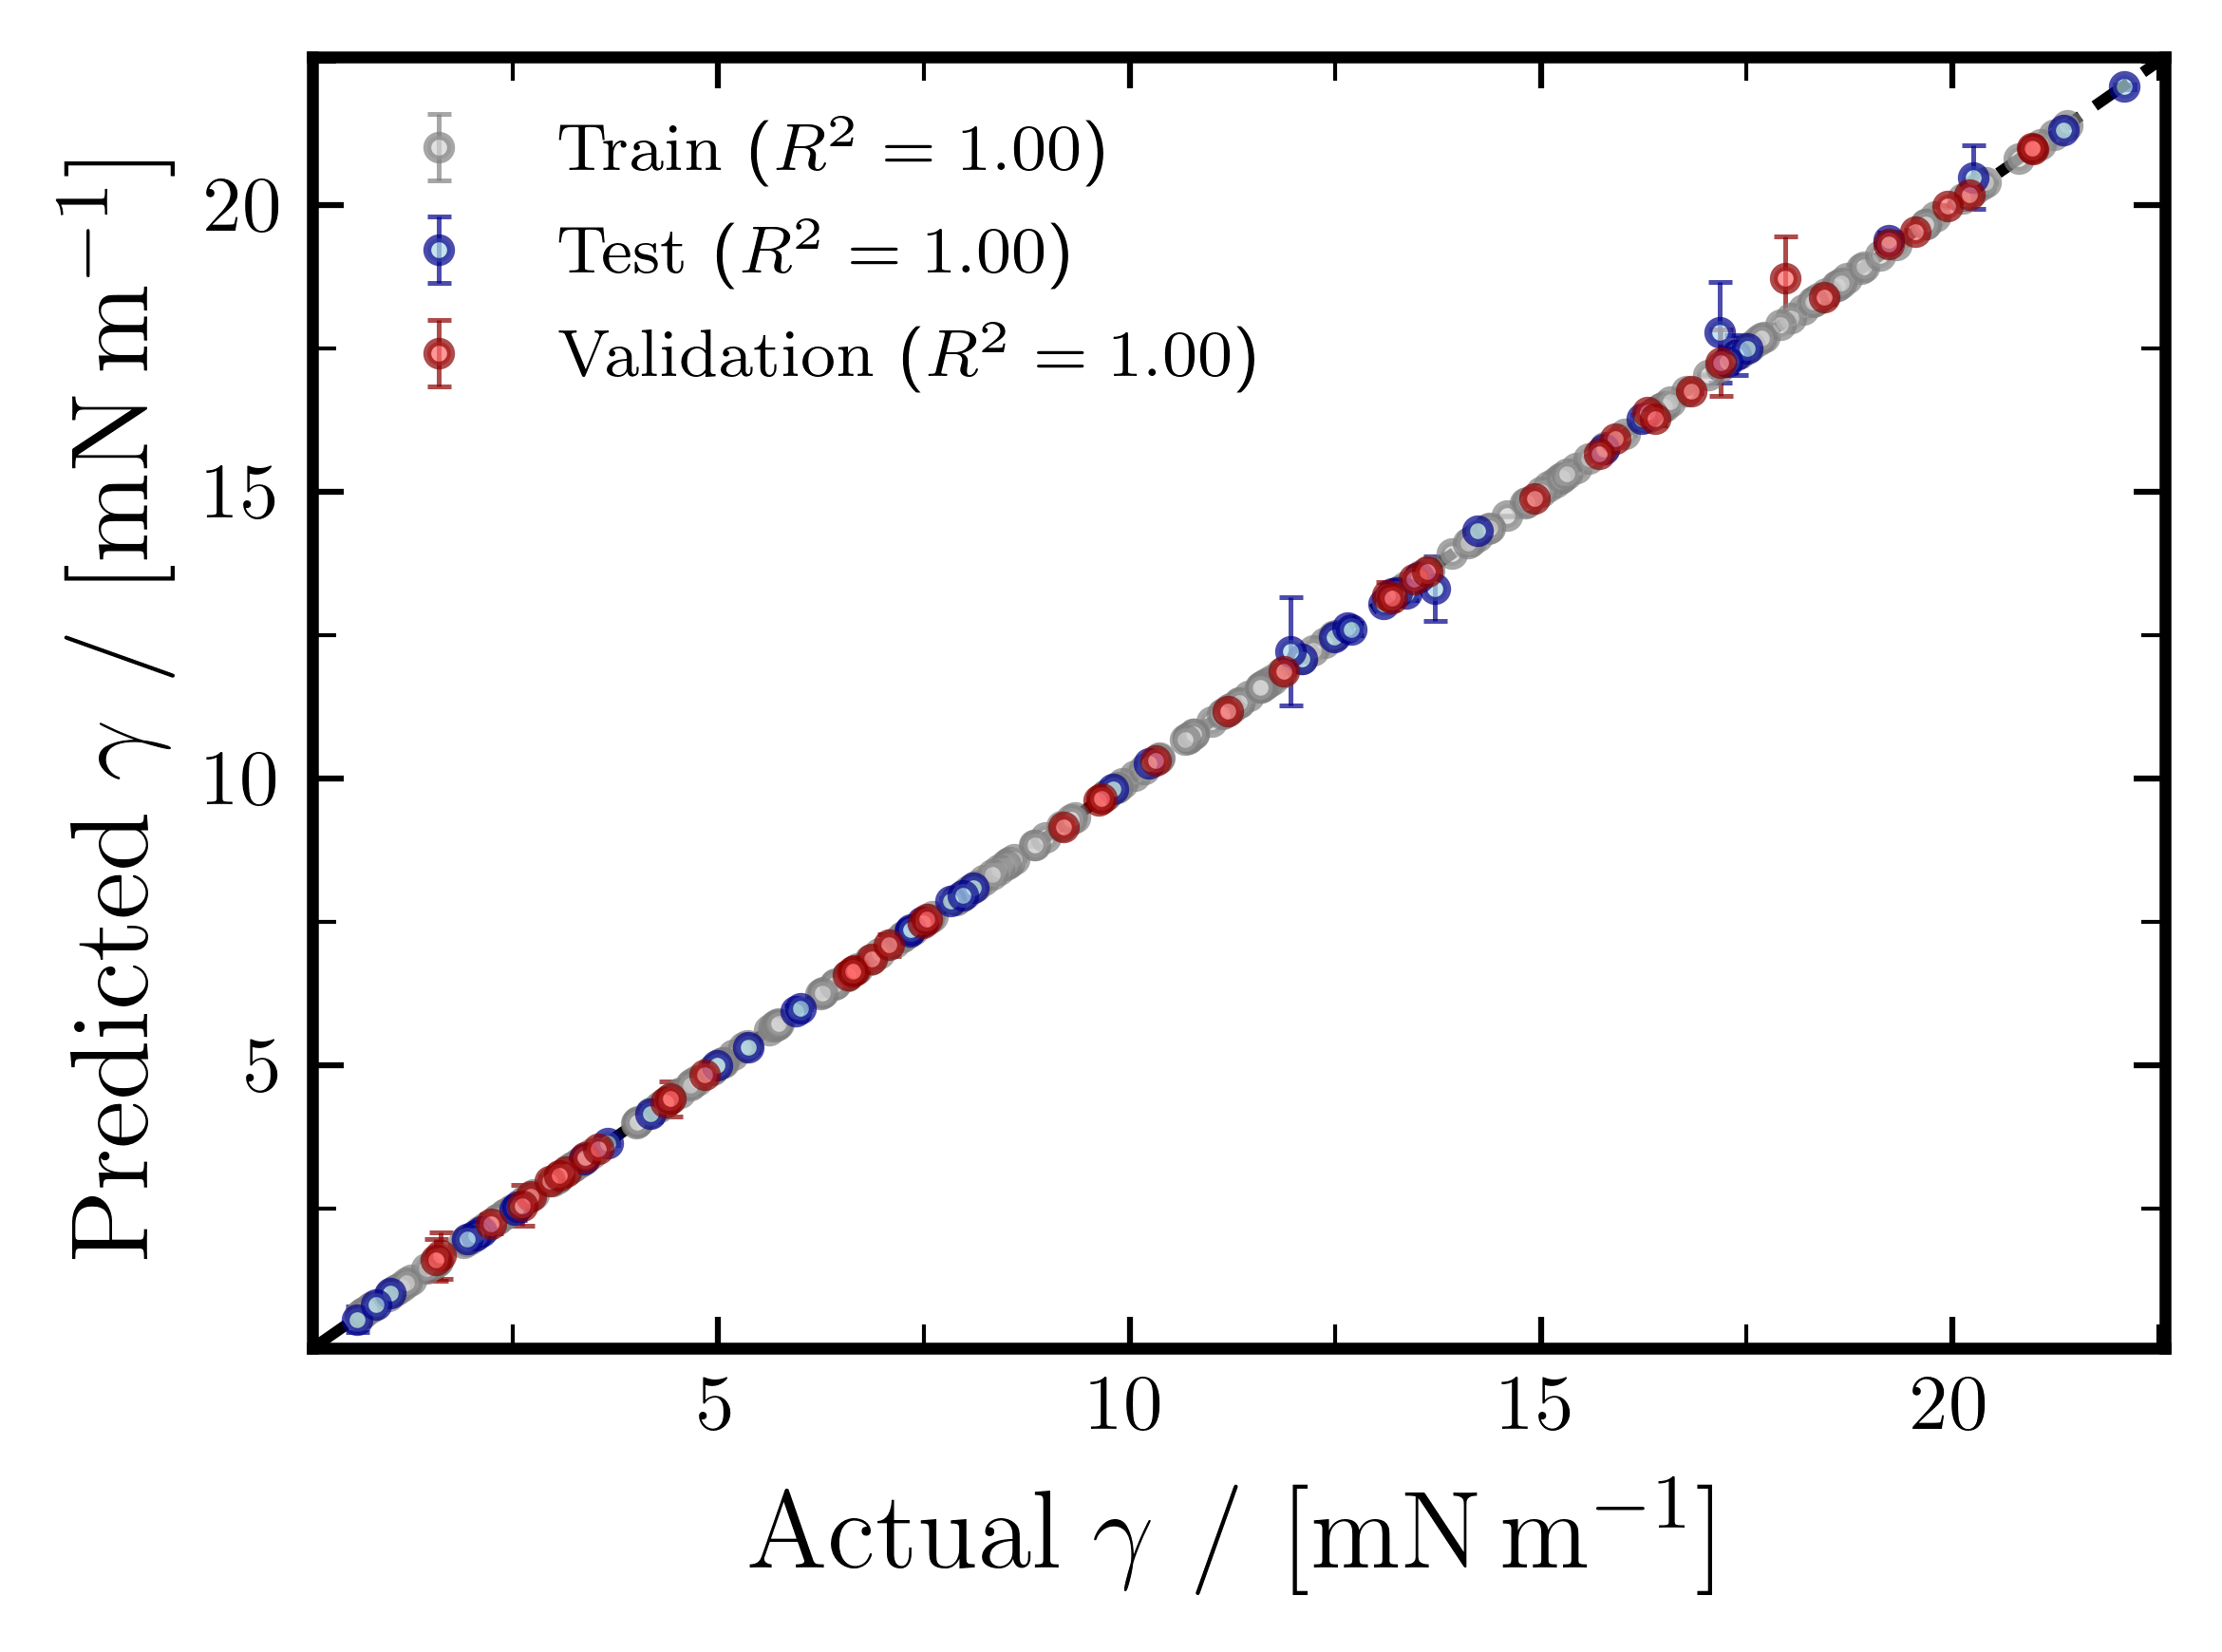

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Actual}\\; {\\gamma}$ / $[\\mathrm{mN\\,m^{-1}}]$', ylabel='$\\mathrm{Predicted}\\;{\\gamma}$ / $[\\mathrm{mN\\,m^{-1}}]$'>)

In [25]:
# Parity plot: gamma_cDFT (actual) vs gamma_pred (reconstructed) with ±2σ uncertainty
post.plot_reconstructed_parity(
    datasets_reconstructed={
        "train": (gamma_cDFT_train, gamma_pred_train, y_train_std),
        "test":  (gamma_cDFT_test,  gamma_pred_test,  y_test_std),
        "val":   (gamma_cDFT_val,   gamma_pred_val,   y_val_std),
    },
    n_sigma=2.0,
    model_name="GPR",
    save_path="GPR_gamma_reconstructed_parity",
    folder=OUTPUT_FOLDER,
)

In [26]:
post.print_summary()

# Collect and save all metrics
if RUN_CV:
    metrics["cv_r2_scores"]   = cv_r2_scores.tolist()
    metrics["cv_r2_mean"]     = float(cv_r2_scores.mean())
    metrics["cv_r2_std"]      = float(cv_r2_scores.std())
    metrics["cv_rmse_scores"] = cv_rmse_scores.tolist()
    metrics["cv_rmse_mean"]   = float(cv_rmse_scores.mean())
    metrics["cv_rmse_std"]    = float(cv_rmse_scores.std())
    metrics["cv_mae_scores"]  = cv_mae_scores.tolist()
    metrics["cv_mae_mean"]    = float(cv_mae_scores.mean())
    metrics["cv_mae_std"]     = float(cv_mae_scores.std())
else:
    metrics["cv_r2_scores"]   = []
    metrics["cv_r2_mean"]     = None
    metrics["cv_r2_std"]      = None
    metrics["cv_rmse_scores"] = []
    metrics["cv_rmse_mean"]   = None
    metrics["cv_rmse_std"]    = None
    metrics["cv_mae_scores"]  = []
    metrics["cv_mae_mean"]    = None
    metrics["cv_mae_std"]     = None

metrics["gamma_cDFT_r2_train"]    = float(gamma_cDFT_r2_train)
metrics["gamma_cDFT_r2_test"]     = float(gamma_cDFT_r2_test)
metrics["gamma_cDFT_r2_val"]      = float(gamma_cDFT_r2_val)
metrics["gamma_cDFT_mae_train_mNm"] = float(gamma_cDFT_mae_train)
metrics["gamma_cDFT_mae_test_mNm"]  = float(gamma_cDFT_mae_test)
metrics["gamma_cDFT_mae_val_mNm"]   = float(gamma_cDFT_mae_val)

metrics["model"]                = "GPR_RBF"
metrics["kernel"]               = str(gpr_model.named_steps["gpr"].kernel_)
metrics["alpha"]                = gpr_model.named_steps["gpr"].alpha
metrics["n_restarts_optimizer"] = gpr_model.named_steps["gpr"].n_restarts_optimizer
metrics["features"]             = features
metrics["target"]               = target
metrics["seed"]                 = SEED

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
metrics_path = os.path.join(OUTPUT_FOLDER, f"GPR_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")

MODEL PERFORMANCE SUMMARY - DELTA_GAMMA
Samples:        45
R² Score:       0.953013
RMSE:           0.128084
MAE:            0.059430
Mean Residual:  -0.015097
Std Residual:   0.127191

FEATURE IMPORTANCES:
------------------------------------------------------------
  P                         |  27.69% | █████████████
  z_hydrogen                |  25.89% | ████████████
  T                         |  25.07% | ████████████
  z_methane                 |   8.06% | ████
  z_carbon_dioxide          |   7.01% | ███
  z_carbon_monoxide         |   2.39% | █
  z_nitrogen                |   1.74% | 
  z_hydrogen_sulfide        |   1.68% | 
  z_argon                   |   0.46% | 

Metrics saved to: GPR_RESIDUAL_OUTPUTS/GPR_residual_metrics.json


In [27]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 1.97 minutes
